In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==========================================================
# 📊 Obtener datos del Fear & Greed Index de Alternative.me
# ==========================================================
url = "https://api.alternative.me/fng/"
params = {"limit": 5000, "format": "json"}

response = requests.get(url, params=params)

if response.status_code == 200:
    data = response.json()["data"]
    df = pd.DataFrame(data)

    # Convertir tipos y limpiar
    df["timestamp"] = pd.to_datetime(df["timestamp"].astype(int), unit="s")
    df["value"] = pd.to_numeric(df["value"])
    df = df.rename(columns={
        "timestamp": "Date",
        "value": "FearGreed_Value",
        "value_classification": "FearGreed_Label"
    })
    df = df.sort_values("Date")

    # Guardar
    # Cambia esta ruta por la que prefieras:
    ruta_guardado = "../data/csv/raw/fear_greed_index.csv"

    # Crear carpeta si no existe
    os.makedirs(os.path.dirname(ruta_guardado), exist_ok=True)

    # Guardar el archivo CSV
    df.to_csv(ruta_guardado)
    print("✅ Fear & Greed Index descargado correctamente")
    print(df.head())
else:
    print("❌ Error al obtener datos:", response.status_code, response.text)


✅ Fear & Greed Index descargado correctamente
      FearGreed_Value FearGreed_Label       Date time_until_update
2963               30            Fear 2018-02-01               NaN
2962               15    Extreme Fear 2018-02-02               NaN
2961               40            Fear 2018-02-03               NaN
2960               24    Extreme Fear 2018-02-04               NaN
2959               11    Extreme Fear 2018-02-05               NaN


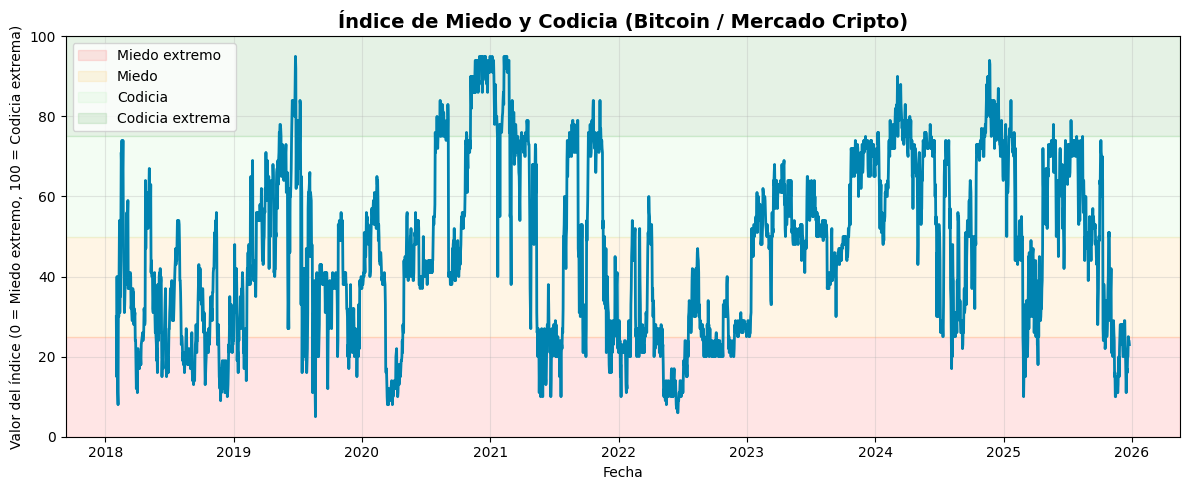

In [7]:
# ==========================================================
# 3️⃣ Gráfica del índice
# ==========================================================
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["FearGreed_Value"], color="#0083B0", linewidth=2)
plt.title("Índice de Miedo y Codicia (Bitcoin / Mercado Cripto)", fontsize=14, weight="bold")
plt.xlabel("Fecha")
plt.ylabel("Valor del índice (0 = Miedo extremo, 100 = Codicia extrema)")
plt.grid(alpha=0.3)
plt.ylim(0, 100)

# Colorear zonas
plt.axhspan(0, 25, color="red", alpha=0.1, label="Miedo extremo")
plt.axhspan(25, 50, color="orange", alpha=0.1, label="Miedo")
plt.axhspan(50, 75, color="lightgreen", alpha=0.1, label="Codicia")
plt.axhspan(75, 100, color="green", alpha=0.1, label="Codicia extrema")

plt.legend()
plt.tight_layout()
plt.show()

Enlace para descargar csv de ethereum, bitcoin histórico, TotalMarketCap, inflación y tipos de interes

https://www.coingecko.com/en/coins/ethereum/historical_data

https://www.coingecko.com/en/charts

https://www.coingecko.com/en/coins/bitcoin/historical_data

https://www.investopedia.com/inflation-rate-by-year-7253832?utm_source=

https://fred.stlouisfed.org/series/FEDFUNDS?utm_source=

Desde el dia 09/11/2017 hasta dia de hoy

In [9]:
import pandas as pd

# ===============================
# 1) Cargar CSVs
# ===============================

btc = pd.read_csv(
    r"C:\Users\josit\CUARTO CURSO\TFG\TFG_DEF\data\csv\raw\btc-usd-max.csv",
    names=["snapped_at","btc_price","btc_mcap","btc_volume"],
    header=0
)

eth = pd.read_csv(
    r"C:\Users\josit\CUARTO CURSO\TFG\TFG_DEF\data\csv\raw\eth-usd-max.csv",
    names=["snapped_at","eth_price","eth_mcap","eth_volume"],
    header=0
)

total = pd.read_csv(
    r"C:\Users\josit\CUARTO CURSO\TFG\TFG_DEF\data\csv\raw\CoinGecko-GlobalCryptoMktCap-2025-12-25.csv",
    names=["snapped_at","total_mcap","total_volume"],
    header=0
)

# ===============================
# 2) Convertir fechas
# ===============================

btc["date"] = pd.to_datetime(btc["snapped_at"]).dt.date
eth["date"] = pd.to_datetime(eth["snapped_at"]).dt.date

# TOTAL tiene timestamps en milisegundos → convertir:
total["date"] = pd.to_datetime(total["snapped_at"], unit="ms").dt.date

# ===============================
# 3) Seleccionar columnas útiles
# ===============================

btc = btc[["date", "btc_mcap"]]
eth = eth[["date", "eth_mcap"]]
total = total[["date", "total_mcap"]]

# ===============================
# 4) Merge OUTER de todo
# ===============================

df = (
    btc.merge(eth, on="date", how="outer")
       .merge(total, on="date", how="outer")
       .sort_values("date")
       .reset_index(drop=True)
)

# ===============================
# 5) Recortar desde que existe ETH
# ===============================

first_eth_date = eth["date"].min()
df = df[df["date"] >= first_eth_date].copy()

# ===============================
# 6) INTERPOLAR total_mcap QUE FALTE
# ===============================

df["total_mcap"] = df["total_mcap"].interpolate(method="linear")

# ===============================
# 7) Calcular dominancias
# ===============================

df["btc_dominance"] = df["btc_mcap"] / df["total_mcap"]
df["eth_dominance"] = df["eth_mcap"] / df["total_mcap"]
df["alt_dominance"] = 1 - df["btc_dominance"] - df["eth_dominance"]

# ===============================
# 8) Guardar dataset final
# ===============================

df.to_csv(
    r"C:\Users\josit\CUARTO CURSO\TFG\TFG_DEF\data\csv\raw\dominance_complete.csv",
    index=False
)

print("DONE!")
print(df.head())
print(df.tail())


DONE!
           date      btc_mcap      eth_mcap    total_mcap  btc_dominance  \
829  2015-08-07  4.015651e+09  0.000000e+00  4.661340e+09       0.861480   
830  2015-08-08  3.745911e+09  8.033948e+07  4.458223e+09       0.840225   
831  2015-08-09  3.811338e+09           NaN  4.453010e+09       0.855902   
832  2015-08-10  3.817350e+09  4.155631e+07  4.496843e+09       0.848896   
833  2015-08-11  3.909601e+09  6.453901e+07  4.619966e+09       0.846240   

     eth_dominance  alt_dominance  
829       0.000000       0.138520  
830       0.018021       0.141754  
831            NaN            NaN  
832       0.009241       0.141863  
833       0.013970       0.139790  
            date      btc_mcap      eth_mcap    total_mcap  btc_dominance  \
4618  2025-12-21  1.762805e+12  3.591869e+11  3.079743e+12       0.572387   
4619  2025-12-22  1.768920e+12  3.625196e+11  3.086834e+12       0.573053   
4620  2025-12-23  1.767081e+12  3.629357e+11  3.082814e+12       0.573204   
4621  2025-12

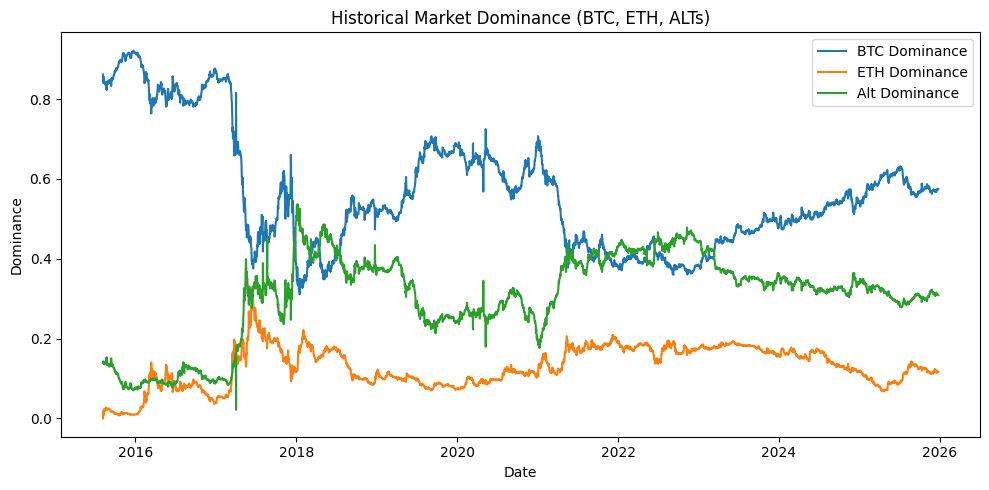

In [10]:


df["date"] = pd.to_datetime(df["date"])

plt.figure(figsize=(10,5))
plt.plot(df["date"], df["btc_dominance"], label="BTC Dominance")
plt.plot(df["date"], df["eth_dominance"], label="ETH Dominance")
plt.plot(df["date"], df["alt_dominance"], label="Alt Dominance")
plt.xlabel("Date")
plt.ylabel("Dominance")
plt.title("Historical Market Dominance (BTC, ETH, ALTs)")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
import pandas as pd

# URL oficial del CPI mensual USA (CPIAUCSL)
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL"

# Descargar
df = pd.read_csv(url)

print("Columnas encontradas:", df.columns.tolist())

# Detectar columna de fecha automáticamente
date_col = None
for col in df.columns:
    if col.lower() in ["date", "date ", "observation_date"]:
        date_col = col
        break

if date_col is None:
    raise ValueError("❌ No se encontró columna de fecha en el CSV.")

# Convertir a datetime
df["date"] = pd.to_datetime(df[date_col])

# Renombrar CPI
value_col = [c for c in df.columns if c != date_col][0]
df = df.rename(columns={value_col: "cpi"})

# Inflación interanual (%)
df["inflation_12m"] = df["cpi"].pct_change(12) * 100

# Guardar CSV
df.to_csv("../data/csv/raw/us_inflation_cpi_fred.csv", index=False)

print("✅ Datos guardados correctamente.")
print(df.head())
print(df.tail())


Columnas encontradas: ['observation_date', 'CPIAUCSL']
✅ Datos guardados correctamente.
  observation_date    cpi       date  inflation_12m
0       1947-01-01  21.48 1947-01-01            NaN
1       1947-02-01  21.62 1947-02-01            NaN
2       1947-03-01  22.00 1947-03-01            NaN
3       1947-04-01  22.00 1947-04-01            NaN
4       1947-05-01  21.95 1947-05-01            NaN
    observation_date      cpi       date  inflation_12m
942       2025-07-01  322.132 2025-07-01       2.731801
943       2025-08-01  323.364 2025-08-01       2.939220
944       2025-09-01  324.368 2025-09-01       3.022700
945       2025-10-01      NaN 2025-10-01       2.789925
946       2025-11-01  325.031 2025-11-01       2.711969


C:\Users\josit\AppData\Local\Temp\ipykernel_43436\928322292.py:29: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["inflation_12m"] = df["cpi"].pct_change(12) * 100


In [17]:
import pandas as pd

# =============================
# 1. Cargar CSV mensual
# =============================
df = pd.read_csv("../data/csv/raw/us_inflation_cpi_fred.csv")

# Asegurar fecha correcta
df["date"] = pd.to_datetime(df["date"])

# =============================
# 2. Crear un rango diario
# =============================
daily_index = pd.date_range(df["date"].min(), df["date"].max(), freq="D")

# Crear dataframe diario vacío
df_daily = pd.DataFrame({"date": daily_index})

# =============================
# 3. Merge diario con mensual
# =============================
df_daily["month"] = df_daily["date"].dt.to_period("M")
df["month"] = df["date"].dt.to_period("M")

df_daily = df_daily.merge(df[["month", "inflation_12m"]], on="month", how="left")

# =============================
# 4. Forward-fill mensual
# =============================
df_daily["inflation_12m"] = df_daily["inflation_12m"].fillna(method="ffill")

# =============================
# 5. Guardar resultado
# =============================
df_daily = df_daily[["date", "inflation_12m"]]
df_daily.to_csv("../data/csv/raw/us_inflation_daily.csv", index=False)

print("✔ Archivo generado: us_inflation_daily.csv")
print(df_daily.head(40))


✔ Archivo generado: us_inflation_daily.csv
         date  inflation_12m
0  1947-01-01            NaN
1  1947-01-02            NaN
2  1947-01-03            NaN
3  1947-01-04            NaN
4  1947-01-05            NaN
5  1947-01-06            NaN
6  1947-01-07            NaN
7  1947-01-08            NaN
8  1947-01-09            NaN
9  1947-01-10            NaN
10 1947-01-11            NaN
11 1947-01-12            NaN
12 1947-01-13            NaN
13 1947-01-14            NaN
14 1947-01-15            NaN
15 1947-01-16            NaN
16 1947-01-17            NaN
17 1947-01-18            NaN
18 1947-01-19            NaN
19 1947-01-20            NaN
20 1947-01-21            NaN
21 1947-01-22            NaN
22 1947-01-23            NaN
23 1947-01-24            NaN
24 1947-01-25            NaN
25 1947-01-26            NaN
26 1947-01-27            NaN
27 1947-01-28            NaN
28 1947-01-29            NaN
29 1947-01-30            NaN
30 1947-01-31            NaN
31 1947-02-01            NaN


C:\Users\josit\AppData\Local\Temp\ipykernel_43436\4137195725.py:30: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_daily["inflation_12m"] = df_daily["inflation_12m"].fillna(method="ffill")


In [18]:
import pandas as pd

# Cargar dataset
df = pd.read_csv("../data/csv/raw/us_inflation_daily.csv")   # o el archivo que quieras
df["date"] = pd.to_datetime(df["date"])

# Fecha límite
cutoff = pd.to_datetime("2018-02-01")

# Filtrar datos (mantener solo >= cutoff)
df_filtered = df[df["date"] >= cutoff].copy()

# Guardar resultado
df_filtered.to_csv("../data/csv/clean/us_inflation_daily_filtered.csv", index=False)

print("✔ Filtrado completado.")
print("Filas nuevas:", len(df_filtered))
print(df_filtered.head())


✔ Filtrado completado.
Filas nuevas: 2861
            date  inflation_12m
25964 2018-02-01       2.263469
25965 2018-02-02       2.263469
25966 2018-02-03       2.263469
25967 2018-02-04       2.263469
25968 2018-02-05       2.263469


📊 Total columnas: 38
✅ Matriz 1 (Precios) guardada: correlation_matrix_1_prices.png



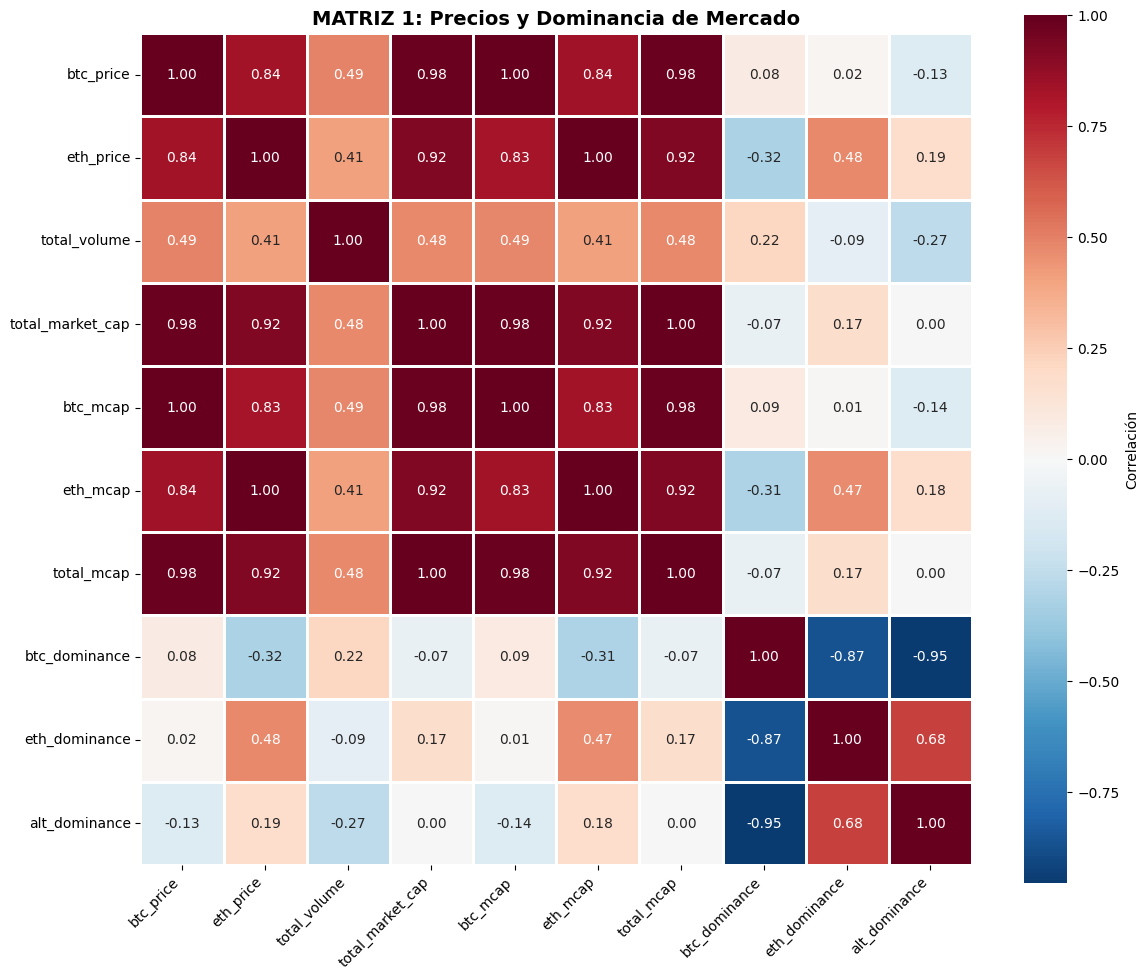

✅ Matriz 2 (Técnicos + Macro) guardada: correlation_matrix_2_technical.png



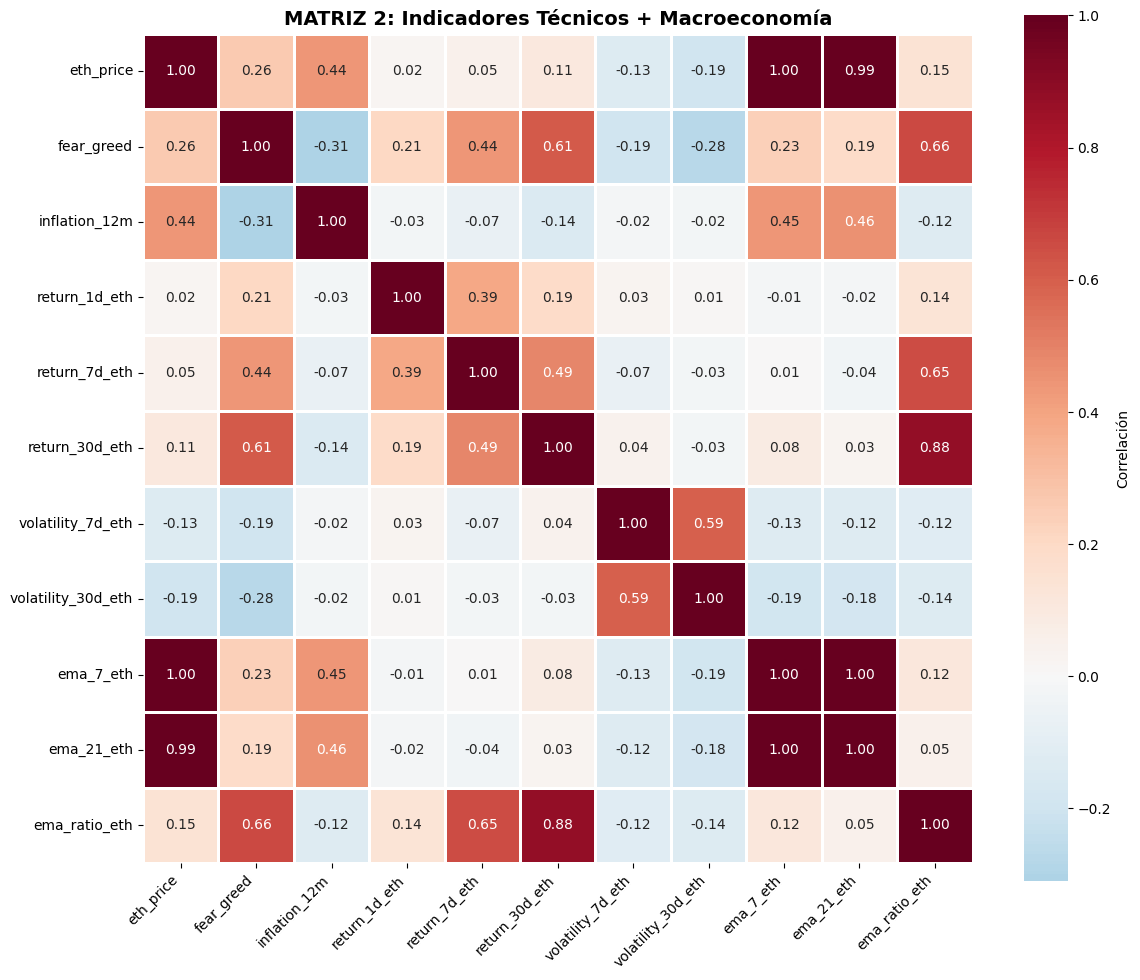


🏆 TOP 15 FEATURES CORRELACIONADAS CON ETH_PRICE
 1. eth_price                 r= 1.0000 ⭐⭐⭐⭐⭐
 2. eth_mcap                  r= 0.9996 ⭐⭐⭐⭐
 3. ema_7_eth                 r= 0.9974 ⭐⭐⭐⭐
 4. ema_21_eth                r= 0.9902 ⭐⭐⭐⭐
 5. total_market_cap          r= 0.9191 ⭐⭐⭐⭐
 6. total_mcap                r= 0.9191 ⭐⭐⭐⭐
 7. btc_price                 r= 0.8360 ⭐⭐⭐⭐
 8. btc_mcap                  r= 0.8289 ⭐⭐⭐⭐
 9. eth_dominance             r= 0.4781 ⭐⭐
10. inflation_12m             r= 0.4405 ⭐⭐
11. total_volume              r= 0.4102 ⭐⭐
12. fear_greed                r= 0.2613 ⭐
13. Greed                     r= 0.2271 ⭐
14. alt_dominance             r= 0.1850 
15. ema_ratio_eth             r= 0.1467 
16. return_30d_eth            r= 0.1088 

✅ Todas las matrices guardadas correctamente


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\josit\CUARTO CURSO\TFG\TFG_DEF\data\csv\clean\crypto_dataset_final.csv")

# Ensure numeric only
numeric_df = df.select_dtypes(include=['float64','int64'])

print(f"📊 Total columnas: {numeric_df.shape[1]}")
print("="*70)

# ============================================================================
# MATRIZ 1: PRECIOS Y DOMINANCIA (Crypto fundamentals)
# ============================================================================

price_columns = [
    'btc_price', 'eth_price', 'total_volume', 
    'total_market_cap', 'btc_mcap', 'eth_mcap', 'total_mcap',
    'btc_dominance', 'eth_dominance', 'alt_dominance'
]

# Filtrar solo las que existen
price_cols_actual = [col for col in price_columns if col in numeric_df.columns]

corr_prices = numeric_df[price_cols_actual].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_prices, 
    annot=True, 
    cmap='RdBu_r', 
    center=0,
    square=True,
    fmt='.2f',
    linewidths=1,
    cbar_kws={'label': 'Correlación'},
    annot_kws={"size": 10}
)
plt.title('MATRIZ 1: Precios y Dominancia de Mercado', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('correlation_matrix_1_prices.png', dpi=300, bbox_inches='tight')
print("✅ Matriz 1 (Precios) guardada: correlation_matrix_1_prices.png\n")
plt.show()

# ============================================================================
# MATRIZ 2: INDICADORES TÉCNICOS + MACRO (RSI, EMA, Fear/Greed, etc)
# ============================================================================

tech_columns = [
    "eth_price",'fear_greed', 'inflation_12m',
    'return_1d_eth', 'return_7d_eth', 'return_30d_eth',
    'volatility_7d_eth', 'volatility_30d_eth',
    'ema_7_eth', 'ema_21_eth', 'ema_ratio_eth'
]

# Filtrar solo las que existen
tech_cols_actual = [col for col in tech_columns if col in numeric_df.columns]

corr_tech = numeric_df[tech_cols_actual].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_tech, 
    annot=True, 
    cmap='RdBu_r', 
    center=0,
    square=True,
    fmt='.2f',
    linewidths=1,
    cbar_kws={'label': 'Correlación'},
    annot_kws={"size": 10}
)
plt.title('MATRIZ 2: Indicadores Técnicos + Macroeconomía', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('correlation_matrix_2_technical.png', dpi=300, bbox_inches='tight')
print("✅ Matriz 2 (Técnicos + Macro) guardada: correlation_matrix_2_technical.png\n")
plt.show()

# ============================================================================
# BONUS: TOP 15 CORRELACIONADAS CON ETH_PRICE
# ============================================================================

print("\n" + "="*70)
print("🏆 TOP 15 FEATURES CORRELACIONADAS CON ETH_PRICE")
print("="*70)

corr_eth = numeric_df.corr()["eth_price"].sort_values(ascending=False)

for i, (feature, corr) in enumerate(corr_eth.head(16).items(), 1):  # 16 incluye eth_price
    stars = '⭐' * int(abs(corr)*5)
    print(f"{i:2d}. {feature:<25} r={corr:>7.4f} {stars}")

print("\n✅ Todas las matrices guardadas correctamente")


In [3]:
# Ejemplo para obtener 3 años de datos en velas de 1 hora
from binance.client import Client
import pandas as pd

client = Client() # No requiere API Key para datos públicos históricos
klines = client.get_historical_klines("ETHUSDT", Client.KLINE_INTERVAL_1HOUR, "1 Jan 2021")

df = pd.DataFrame(klines, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_av', 'trades', 'tb_base_av', 'tb_quote_av', 'ignore'])
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df.to_csv('eth_historical_1h.csv', index=False)

In [6]:
import json
import pandas as pd

# Copia tu JSON (el que acabas de mandar)
json_str = '[{"date":"2024-01-15","rsi":58.454306454766424},{"date":"2024-01-16","rsi":61.793317019976776},{"date":"2024-01-17","rsi":57.89858569773963},{"date":"2024-01-18","rsi":54.10080998331812},{"date":"2024-01-19","rsi":55.25885799085094},{"date":"2024-01-20","rsi":53.960336193669775},{"date":"2024-01-21","rsi":52.90615843858524},{"date":"2024-01-22","rsi":44.3829459515225},{"date":"2024-01-23","rsi":40.9042271186962},{"date":"2024-01-24","rsi":40.55651934789854},{"date":"2024-01-25","rsi":39.74692021191419},{"date":"2024-01-26","rsi":43.53661398331087},{"date":"2024-01-27","rsi":43.58959932401106},{"date":"2024-01-28","rsi":42.91485379834396},{"date":"2024-01-29","rsi":47.7936071535144},{"date":"2024-01-30","rsi":49.90645774132254},{"date":"2024-01-31","rsi":45.43418022156659},{"date":"2024-02-01","rsi":47.18505646233368},{"date":"2024-02-02","rsi":47.54394104791002},{"date":"2024-02-03","rsi":46.573256702118044},{"date":"2024-02-04","rsi":46.025764447089564},{"date":"2024-02-05","rsi":46.99150968285262},{"date":"2024-02-06","rsi":53.95389075130404},{"date":"2024-02-07","rsi":58.11881749220835},{"date":"2024-02-08","rsi":57.70024557730258},{"date":"2024-02-09","rsi":62.78424156306982},{"date":"2024-02-10","rsi":63.736249419932086},{"date":"2024-02-11","rsi":64.19249149853873},{"date":"2024-02-12","rsi":72.90616555758332},{"date":"2024-02-13","rsi":70.93889541523893},{"date":"2024-02-14","rsi":76.70567440643887},{"date":"2024-02-15","rsi":78.29416128681571},{"date":"2024-02-16","rsi":75.81587377123603},{"date":"2024-02-17","rsi":73.74775894915494},{"date":"2024-02-18","rsi":77.35636503521935},{"date":"2024-02-19","rsi":79.48092700706859},{"date":"2024-02-20","rsi":81.50465008646559},{"date":"2024-02-21","rsi":76.4916594132272},{"date":"2024-02-22","rsi":76.51515597222982},{"date":"2024-02-23","rsi":70.74898570156398},{"date":"2024-02-24","rsi":73.79681293080334},{"date":"2024-02-25","rsi":77.99670409827712},{"date":"2024-02-26","rsi":79.90778756705161},{"date":"2024-02-27","rsi":81.60808424365811},{"date":"2024-02-28","rsi":84.62680404588868},{"date":"2024-02-29","rsi":80.22892910199168},{"date":"2024-03-01","rsi":82.33218955639991},{"date":"2024-03-02","rsi":81.03592812085964},{"date":"2024-03-03","rsi":82.6000582301949},{"date":"2024-03-04","rsi":85.24987026514994},{"date":"2024-03-05","rsi":78.29972577690643},{"date":"2024-03-06","rsi":83.40237150771621},{"date":"2024-03-07","rsi":84.23507934816355},{"date":"2024-03-08","rsi":84.50412751286365},{"date":"2024-03-09","rsi":84.87079035205612},{"date":"2024-03-10","rsi":81.81590609205118},{"date":"2024-03-11","rsi":84.96949546100434},{"date":"2024-03-12","rsi":78.17771572483305},{"date":"2024-03-13","rsi":78.73395071979682},{"date":"2024-03-14","rsi":69.72045285191186},{"date":"2024-03-15","rsi":60.738230480357615},{"date":"2024-03-16","rsi":50.64964409047984},{"date":"2024-03-17","rsi":55.16466939179791},{"date":"2024-03-18","rsi":50.03396045226323},{"date":"2024-03-19","rsi":38.78339941232029},{"date":"2024-03-20","rsi":50.59470207751213},{"date":"2024-03-21","rsi":49.998950384568346},{"date":"2024-03-22","rsi":45.49430630235311},{"date":"2024-03-23","rsi":45.59060977220405},{"date":"2024-03-24","rsi":49.49412565790108},{"date":"2024-03-25","rsi":53.629357120804954},{"date":"2024-03-26","rsi":53.51234591144457},{"date":"2024-03-27","rsi":50.44655241263312},{"date":"2024-03-28","rsi":52.49829717702729},{"date":"2024-03-29","rsi":50.67066618201825},{"date":"2024-03-30","rsi":50.522855072187134},{"date":"2024-03-31","rsi":55.57867405389685},{"date":"2024-04-01","rsi":49.965655805108455},{"date":"2024-04-02","rsi":42.57962215336681},{"date":"2024-04-03","rsi":43.92023019348202},{"date":"2024-04-04","rsi":44.676538598189204},{"date":"2024-04-05","rsi":44.290713027015386},{"date":"2024-04-06","rsi":45.883288690044566},{"date":"2024-04-07","rsi":50.196991035312934},{"date":"2024-04-08","rsi":58.80667869586775},{"date":"2024-04-09","rsi":51.29725051592855},{"date":"2024-04-10","rsi":52.619185571742776},{"date":"2024-04-11","rsi":51.12794648944079},{"date":"2024-04-12","rsi":42.327164140584784},{"date":"2024-04-13","rsi":36.22812093756194},{"date":"2024-04-14","rsi":41.976808500547094},{"date":"2024-04-15","rsi":40.54415453871822},{"date":"2024-04-16","rsi":40.09991996760874},{"date":"2024-04-17","rsi":37.445894964731195},{"date":"2024-04-18","rsi":40.8659939189934},{"date":"2024-04-19","rsi":40.66721418942879},{"date":"2024-04-20","rsi":44.87507060337172},{"date":"2024-04-21","rsi":44.517648485667365},{"date":"2024-04-22","rsi":46.91205429181174},{"date":"2024-04-23","rsi":47.72802937483796},{"date":"2024-04-24","rsi":44.49676765908874},{"date":"2024-04-25","rsi":45.32797530543167},{"date":"2024-04-26","rsi":44.203624962532515},{"date":"2024-04-27","rsi":50.3461847641183},{"date":"2024-04-28","rsi":50.85274373162376},{"date":"2024-04-29","rsi":48.47541100925782},{"date":"2024-04-30","rsi":39.864231178521806},{"date":"2024-05-01","rsi":38.33005918828582},{"date":"2024-05-02","rsi":39.41612678770716},{"date":"2024-05-03","rsi":45.86016332476627},{"date":"2024-05-04","rsi":46.604177132417526},{"date":"2024-05-05","rsi":47.689356076876294},{"date":"2024-05-06","rsi":44.03823795562875},{"date":"2024-05-07","rsi":41.462329788475934},{"date":"2024-05-08","rsi":39.985652501044534},{"date":"2024-05-09","rsi":44.05084709976584},{"date":"2024-05-10","rsi":38.38342067636222},{"date":"2024-05-11","rsi":38.50565340070972},{"date":"2024-05-12","rsi":39.72165539035729},{"date":"2024-05-13","rsi":41.23346680008683},{"date":"2024-05-14","rsi":37.857571715227316},{"date":"2024-05-15","rsi":48.281230143243775},{"date":"2024-05-16","rsi":43.63359709416352},{"date":"2024-05-17","rsi":51.74177962501357},{"date":"2024-05-18","rsi":53.146307887031874},{"date":"2024-05-19","rsi":50.34888949929205},{"date":"2024-05-20","rsi":70.0290226339284},{"date":"2024-05-21","rsi":72.5152473630361},{"date":"2024-05-22","rsi":69.92145903528065},{"date":"2024-05-23","rsi":70.7794376300923},{"date":"2024-05-24","rsi":68.14404324969564},{"date":"2024-05-25","rsi":68.70386669518618},{"date":"2024-05-26","rsi":70.61545450131838},{"date":"2024-05-27","rsi":72.19282092663354},{"date":"2024-05-28","rsi":69.06730364014805},{"date":"2024-05-29","rsi":64.58346577438687},{"date":"2024-05-30","rsi":63.639639618413156},{"date":"2024-05-31","rsi":64.09514433498948},{"date":"2024-06-01","rsi":65.94888817247566},{"date":"2024-06-02","rsi":63.79402682477856},{"date":"2024-06-03","rsi":62.80160954130963},{"date":"2024-06-04","rsi":64.68294720215697},{"date":"2024-06-05","rsi":66.71657350518079},{"date":"2024-06-06","rsi":62.756512475682044},{"date":"2024-06-07","rsi":54.033765166480386},{"date":"2024-06-08","rsi":54.15353368966021},{"date":"2024-06-09","rsi":55.49626806615105},{"date":"2024-06-10","rsi":52.87727971798999},{"date":"2024-06-11","rsi":43.399374509235756},{"date":"2024-06-12","rsi":47.11491260276469},{"date":"2024-06-13","rsi":42.66871789510876},{"date":"2024-06-14","rsi":43.36893195993356},{"date":"2024-06-15","rsi":48.613215328787646},{"date":"2024-06-16","rsi":51.71939541642951},{"date":"2024-06-17","rsi":45.80197979431326},{"date":"2024-06-18","rsi":44.41374436577561},{"date":"2024-06-19","rsi":48.96459436888221},{"date":"2024-06-20","rsi":46.35770850184954},{"date":"2024-06-21","rsi":46.673759204957584},{"date":"2024-06-22","rsi":45.44478215870556},{"date":"2024-06-23","rsi":41.252400497693294},{"date":"2024-06-24","rsi":37.87684454599518},{"date":"2024-06-25","rsi":41.26687119558284},{"date":"2024-06-26","rsi":39.927756017514085},{"date":"2024-06-27","rsi":45.53824464156207},{"date":"2024-06-28","rsi":41.586421413689735},{"date":"2024-06-29","rsi":41.54996787881255},{"date":"2024-06-30","rsi":46.11258266321773},{"date":"2024-07-01","rsi":46.670162834838855},{"date":"2024-07-02","rsi":45.05427692781874},{"date":"2024-07-03","rsi":37.801004329445966},{"date":"2024-07-04","rsi":28.31885974336682},{"date":"2024-07-05","rsi":26.15737864838116},{"date":"2024-07-06","rsi":32.80578978939832},{"date":"2024-07-07","rsi":28.412303373156373},{"date":"2024-07-08","rsi":34.446372893123176},{"date":"2024-07-09","rsi":37.33072549673933},{"date":"2024-07-10","rsi":39.7377389617525},{"date":"2024-07-11","rsi":39.656636739239026},{"date":"2024-07-12","rsi":41.942935740780804},{"date":"2024-07-13","rsi":44.808168235784706},{"date":"2024-07-14","rsi":49.018615986585466},{"date":"2024-07-15","rsi":60.82992718959752},{"date":"2024-07-16","rsi":58.11067230083277},{"date":"2024-07-17","rsi":54.96339081069408},{"date":"2024-07-18","rsi":56.69340355107643},{"date":"2024-07-19","rsi":60.18370727919605},{"date":"2024-07-20","rsi":60.76475085006863},{"date":"2024-07-21","rsi":61.53637609250614},{"date":"2024-07-22","rsi":55.05694123047912},{"date":"2024-07-23","rsi":57.15687022606427},{"date":"2024-07-24","rsi":48.59103978486888},{"date":"2024-07-25","rsi":41.199613836598544},{"date":"2024-07-26","rsi":46.67686040539747},{"date":"2024-07-27","rsi":45.405243711246996},{"date":"2024-07-28","rsi":46.72093147897737},{"date":"2024-07-29","rsi":49.42117134118201},{"date":"2024-07-30","rsi":47.222112056815},{"date":"2024-07-31","rsi":44.79365760036054},{"date":"2024-08-01","rsi":43.289000300030985},{"date":"2024-08-02","rsi":34.29465567047433},{"date":"2024-08-03","rsi":31.585476081428038},{"date":"2024-08-04","rsi":25.81754544935027},{"date":"2024-08-05","rsi":20.75405410211792},{"date":"2024-08-06","rsi":23.254082751143006},{"date":"2024-08-07","rsi":21.14114668837861},{"date":"2024-08-08","rsi":38.28651557074785},{"date":"2024-08-09","rsi":36.237198944757175},{"date":"2024-08-10","rsi":36.69140122709249},{"date":"2024-08-11","rsi":35.219990198278666},{"date":"2024-08-12","rsi":42.68379594897494},{"date":"2024-08-13","rsi":42.051011189567234},{"date":"2024-08-14","rsi":40.77302610179232},{"date":"2024-08-15","rsi":37.94453353902895},{"date":"2024-08-16","rsi":39.07709188301671},{"date":"2024-08-17","rsi":40.164627038170295},{"date":"2024-08-18","rsi":40.12167185357381},{"date":"2024-08-19","rsi":41.47862055501626},{"date":"2024-08-20","rsi":38.93165487868772},{"date":"2024-08-21","rsi":42.390499927326566},{"date":"2024-08-22","rsi":42.01920092775194},{"date":"2024-08-23","rsi":49.93282377692771},{"date":"2024-08-24","rsi":50.18857600823553},{"date":"2024-08-25","rsi":49.08330941301441},{"date":"2024-08-26","rsi":45.4687204453634},{"date":"2024-08-27","rsi":36.076862282008356},{"date":"2024-08-28","rsi":40.23843340521299},{"date":"2024-08-29","rsi":40.261103881614495},{"date":"2024-08-30","rsi":40.131981132012626},{"date":"2024-08-31","rsi":39.560374969632086},{"date":"2024-09-01","rsi":35.78462925180571},{"date":"2024-09-02","rsi":43.30234972566414},{"date":"2024-09-03","rsi":38.17137281684712},{"date":"2024-09-04","rsi":40.018321401960314},{"date":"2024-09-05","rsi":36.643126134838525},{"date":"2024-09-06","rsi":31.565970149233273},{"date":"2024-09-07","rsi":34.95482165300555},{"date":"2024-09-08","rsi":36.517512331643445},{"date":"2024-09-09","rsi":40.57507239999658},{"date":"2024-09-10","rsi":42.58369357473646},{"date":"2024-09-11","rsi":40.240873441642975},{"date":"2024-09-12","rsi":41.762883869593466},{"date":"2024-09-13","rsi":47.047232127612205},{"date":"2024-09-14","rsi":45.75824651562911},{"date":"2024-09-15","rsi":40.66429238291613},{"date":"2024-09-16","rsi":39.425142222587176},{"date":"2024-09-17","rsi":42.82584912337259},{"date":"2024-09-18","rsi":44.838832492164215},{"date":"2024-09-19","rsi":51.12330082395459},{"date":"2024-09-20","rsi":56.52959990104183},{"date":"2024-09-21","rsi":59.2879701818421},{"date":"2024-09-22","rsi":56.944412219359904},{"date":"2024-09-23","rsi":60.30806797481273},{"date":"2024-09-24","rsi":60.60119420925537},{"date":"2024-09-25","rsi":54.95982284427473},{"date":"2024-09-26","rsi":57.930888777610654},{"date":"2024-09-27","rsi":61.25115238867009},{"date":"2024-09-28","rsi":59.78641312816164},{"date":"2024-09-29","rsi":58.298870570036584},{"date":"2024-09-30","rsi":53.83590763122742},{"date":"2024-10-01","rsi":43.919793657357125},{"date":"2024-10-02","rsi":39.64963038240502},{"date":"2024-10-03","rsi":38.89819782627303},{"date":"2024-10-04","rsi":43.73279389144204},{"date":"2024-10-05","rsi":43.794529384905815},{"date":"2024-10-06","rsi":45.6586223810023},{"date":"2024-10-07","rsi":44.47274787820073},{"date":"2024-10-08","rsi":45.974155364835845},{"date":"2024-10-09","rsi":41.214806513142925},{"date":"2024-10-10","rsi":42.607412914519834},{"date":"2024-10-11","rsi":47.16469134121063},{"date":"2024-10-12","rsi":50.388270712085536},{"date":"2024-10-13","rsi":49.666741663180176},{"date":"2024-10-14","rsi":60.70934271054781},{"date":"2024-10-15","rsi":58.739976151323944},{"date":"2024-10-16","rsi":59.0575808323043},{"date":"2024-10-17","rsi":58.40676680420557},{"date":"2024-10-18","rsi":60.937575243930276},{"date":"2024-10-19","rsi":61.419377142509354},{"date":"2024-10-20","rsi":67.3785192112133},{"date":"2024-10-21","rsi":59.243993428266705},{"date":"2024-10-22","rsi":55.194281086173966},{"date":"2024-10-23","rsi":46.78709815342424},{"date":"2024-10-24","rsi":48.71059213597799},{"date":"2024-10-25","rsi":42.31804393382985},{"date":"2024-10-26","rsi":45.71705746141419},{"date":"2024-10-27","rsi":47.71805994652631},{"date":"2024-10-28","rsi":52.01483339598568},{"date":"2024-10-29","rsi":56.69894598370292},{"date":"2024-10-30","rsi":57.882825099571775},{"date":"2024-10-31","rsi":47.65183219933878},{"date":"2024-11-01","rsi":47.402397884001594},{"date":"2024-11-02","rsi":46.022447031067756},{"date":"2024-11-03","rsi":43.74035178078312},{"date":"2024-11-04","rsi":40.07141891645088},{"date":"2024-11-05","rsi":42.31916974173336},{"date":"2024-11-06","rsi":60.90211251906123},{"date":"2024-11-07","rsi":67.34345288987404},{"date":"2024-11-08","rsi":69.4526994573545},{"date":"2024-11-09","rsi":74.02552552540749},{"date":"2024-11-10","rsi":75.43703574697058},{"date":"2024-11-11","rsi":79.15579234349168},{"date":"2024-11-12","rsi":71.04046245694644},{"date":"2024-11-13","rsi":67.91066963926833},{"date":"2024-11-14","rsi":60.73395522151951},{"date":"2024-11-15","rsi":62.15490295304625},{"date":"2024-11-16","rsi":63.139896073283},{"date":"2024-11-17","rsi":59.93848047659671},{"date":"2024-11-18","rsi":64.39898869384477},{"date":"2024-11-19","rsi":59.21722007722165},{"date":"2024-11-20","rsi":57.20329123229029},{"date":"2024-11-21","rsi":66.29967832904998},{"date":"2024-11-22","rsi":64.78761791253174},{"date":"2024-11-23","rsi":66.58813391876707},{"date":"2024-11-24","rsi":64.790323526752},{"date":"2024-11-25","rsi":66.29172875572657},{"date":"2024-11-26","rsi":61.374727857741064},{"date":"2024-11-27","rsi":70.36948483313284},{"date":"2024-11-28","rsi":66.46662237695423},{"date":"2024-11-29","rsi":66.81682872282133},{"date":"2024-11-30","rsi":69.61898890271529},{"date":"2024-12-01","rsi":69.75283128044924},{"date":"2024-12-02","rsi":65.91710405896727},{"date":"2024-12-03","rsi":64.57585757267435},{"date":"2024-12-04","rsi":70.62266167693063},{"date":"2024-12-05","rsi":68.88227481716419},{"date":"2024-12-06","rsi":73.41488228753808},{"date":"2024-12-07","rsi":73.23102532215695},{"date":"2024-12-08","rsi":73.30058624289161},{"date":"2024-12-09","rsi":57.86844097735191},{"date":"2024-12-10","rsi":54.1528688201521},{"date":"2024-12-11","rsi":60.476808042698025},{"date":"2024-12-12","rsi":61.8928816346671},{"date":"2024-12-13","rsi":62.69739109930238},{"date":"2024-12-14","rsi":60.59914650303215},{"date":"2024-12-15","rsi":63.18857173004561},{"date":"2024-12-16","rsi":64.26460087575046},{"date":"2024-12-17","rsi":59.00121802205316},{"date":"2024-12-18","rsi":47.78661950557392},{"date":"2024-12-19","rsi":41.42995624601429},{"date":"2024-12-20","rsi":43.62619534851097},{"date":"2024-12-21","rsi":39.6585990638464},{"date":"2024-12-22","rsi":38.01641906181846},{"date":"2024-12-23","rsi":43.819246502941205},{"date":"2024-12-24","rsi":46.77919946451395},{"date":"2024-12-25","rsi":46.82609895864916},{"date":"2024-12-26","rsi":41.45044205458435},{"date":"2024-12-27","rsi":41.37753346683544},{"date":"2024-12-28","rsi":44.517475048091825},{"date":"2024-12-29","rsi":42.786320086954206},{"date":"2024-12-30","rsi":43.12494108652483},{"date":"2024-12-31","rsi":42.19217893165804},{"date":"2025-01-01","rsi":43.35195202314212},{"date":"2025-01-02","rsi":48.54129620092614},{"date":"2025-01-03","rsi":55.4399631526645},{"date":"2025-01-04","rsi":57.542724904355566},{"date":"2025-01-05","rsi":56.26208642802424},{"date":"2025-01-06","rsi":58.55597734730201},{"date":"2025-01-07","rsi":44.42293976615605},{"date":"2025-01-08","rsi":42.43805716887742},{"date":"2025-01-09","rsi":38.82344894375444},{"date":"2025-01-10","rsi":41.2463248411547},{"date":"2025-01-11","rsi":42.004349248933195},{"date":"2025-01-12","rsi":41.36949409370833},{"date":"2025-01-13","rsi":36.59293482480349},{"date":"2025-01-14","rsi":41.50938096052245},{"date":"2025-01-15","rsi":51.85192673754395},{"date":"2025-01-16","rsi":46.32284672239299},{"date":"2025-01-17","rsi":52.66019928787698},{"date":"2025-01-18","rsi":46.638827363719024},{"date":"2025-01-19","rsi":43.55364478892831},{"date":"2025-01-20","rsi":46.28345953234967},{"date":"2025-01-21","rsi":48.21139071662496},{"date":"2025-01-22","rsi":45.1310543054095},{"date":"2025-01-23","rsi":48.93892324535376},{"date":"2025-01-24","rsi":47.98404189206989},{"date":"2025-01-25","rsi":48.31703740654677},{"date":"2025-01-26","rsi":45.05049834620827},{"date":"2025-01-27","rsi":42.85052132523879},{"date":"2025-01-28","rsi":39.18369551401218},{"date":"2025-01-29","rsi":41.09708177588378},{"date":"2025-01-30","rsi":47.746492459612014},{"date":"2025-01-31","rsi":50.02233687196658},{"date":"2025-02-01","rsi":42.857678786470515},{"date":"2025-02-02","rsi":35.303012080973254},{"date":"2025-02-03","rsi":36.07465700685133},{"date":"2025-02-04","rsi":32.181271262773784},{"date":"2025-02-05","rsi":34.85161342830639},{"date":"2025-02-06","rsi":32.27241466920449},{"date":"2025-02-07","rsi":30.645684615275403},{"date":"2025-02-08","rsi":31.21528383479497},{"date":"2025-02-09","rsi":31.117505140787706},{"date":"2025-02-10","rsi":33.156973033641805},{"date":"2025-02-11","rsi":31.357768314391954},{"date":"2025-02-12","rsi":39.481775853536604},{"date":"2025-02-13","rsi":37.318459943906355},{"date":"2025-02-14","rsi":40.22075607815794},{"date":"2025-02-15","rsi":38.96147924876362},{"date":"2025-02-16","rsi":37.77730233505927},{"date":"2025-02-17","rsi":42.72865608741582},{"date":"2025-02-18","rsi":39.591623507048354},{"date":"2025-02-19","rsi":42.45196987371666},{"date":"2025-02-20","rsi":43.96673144571555},{"date":"2025-02-21","rsi":40.22695980255466},{"date":"2025-02-22","rsi":46.556230533968765},{"date":"2025-02-23","rsi":49.70387642014014},{"date":"2025-02-24","rsi":37.07912632139293},{"date":"2025-02-25","rsi":36.4236747060165},{"date":"2025-02-26","rsi":31.601682831057836},{"date":"2025-02-27","rsi":30.89620248545725},{"date":"2025-02-28","rsi":29.07700563523784},{"date":"2025-03-01","rsi":28.508258045690688},{"date":"2025-03-02","rsi":45.01649147610675},{"date":"2025-03-03","rsi":34.44285793133372},{"date":"2025-03-04","rsi":35.50859817549256},{"date":"2025-03-05","rsi":38.6699280070075},{"date":"2025-03-06","rsi":37.58095100624738},{"date":"2025-03-07","rsi":35.834216803004864},{"date":"2025-03-08","rsi":38.848525716724005},{"date":"2025-03-09","rsi":33.76654787760599},{"date":"2025-03-10","rsi":30.232082158553375},{"date":"2025-03-11","rsi":33.099640957821244},{"date":"2025-03-12","rsi":32.830703464101255},{"date":"2025-03-13","rsi":31.65730048080172},{"date":"2025-03-14","rsi":34.21602756109056},{"date":"2025-03-15","rsi":35.7714146415473},{"date":"2025-03-16","rsi":34.21298636215147},{"date":"2025-03-17","rsi":36.569954878143626},{"date":"2025-03-18","rsi":36.910802198073476},{"date":"2025-03-19","rsi":44.20711033899452},{"date":"2025-03-20","rsi":41.11328757811803},{"date":"2025-03-21","rsi":40.41856067598722},{"date":"2025-03-22","rsi":41.35815740062581},{"date":"2025-03-23","rsi":42.968869123802484},{"date":"2025-03-24","rsi":47.41342018687992},{"date":"2025-03-25","rsi":46.88382641730129},{"date":"2025-03-26","rsi":43.713402928015185},{"date":"2025-03-27","rsi":43.34523083759541},{"date":"2025-03-28","rsi":37.96006771144897},{"date":"2025-03-29","rsi":34.974202431032204},{"date":"2025-03-30","rsi":34.08073123419742},{"date":"2025-03-31","rsi":35.53158099211601},{"date":"2025-04-01","rsi":42.056818255880735},{"date":"2025-04-02","rsi":36.68475578560357},{"date":"2025-04-03","rsi":38.25161383116454},{"date":"2025-04-04","rsi":38.23647041339324},{"date":"2025-04-05","rsi":37.73775518747285},{"date":"2025-04-06","rsi":28.079794492186778},{"date":"2025-04-07","rsi":27.372679993801956},{"date":"2025-04-08","rsi":24.785960790061203},{"date":"2025-04-09","rsi":39.372774929720286},{"date":"2025-04-10","rsi":34.075027898628484},{"date":"2025-04-11","rsi":36.88018029810725},{"date":"2025-04-12","rsi":41.470088114008},{"date":"2025-04-13","rsi":39.5696424668466},{"date":"2025-04-14","rsi":41.18593651020154},{"date":"2025-04-15","rsi":39.68976045749748},{"date":"2025-04-16","rsi":39.216646203678216},{"date":"2025-04-17","rsi":39.54419150876578},{"date":"2025-04-18","rsi":40.043549212729864},{"date":"2025-04-19","rsi":41.98576221244108},{"date":"2025-04-20","rsi":40.49022003736131},{"date":"2025-04-21","rsi":40.020173153368006},{"date":"2025-04-22","rsi":53.33753206836798},{"date":"2025-04-23","rsi":55.65254765074593},{"date":"2025-04-24","rsi":53.708133642973365},{"date":"2025-04-25","rsi":54.79592705404105},{"date":"2025-04-26","rsi":57.074574164105485},{"date":"2025-04-27","rsi":54.633049868329984},{"date":"2025-04-28","rsi":55.06020498021512},{"date":"2025-04-29","rsi":55.08484342259189},{"date":"2025-04-30","rsi":54.54783467404122},{"date":"2025-05-01","rsi":58.237607371317324},{"date":"2025-05-02","rsi":58.51581712295497},{"date":"2025-05-03","rsi":57.46708549976647},{"date":"2025-05-04","rsi":54.47401752420821},{"date":"2025-05-05","rsi":55.5700515635228},{"date":"2025-05-06","rsi":54.97822413605301},{"date":"2025-05-07","rsi":54.50620145310846},{"date":"2025-05-08","rsi":77.79695247815378},{"date":"2025-05-09","rsi":81.40524758452895},{"date":"2025-05-10","rsi":85.67778644472075},{"date":"2025-05-11","rsi":79.67111882161518},{"date":"2025-05-12","rsi":78.53426046500964},{"date":"2025-05-13","rsi":82.17132420788332},{"date":"2025-05-14","rsi":76.82542884658386},{"date":"2025-05-15","rsi":72.25850783052108},{"date":"2025-05-16","rsi":71.49388663070538},{"date":"2025-05-17","rsi":67.10904674316964},{"date":"2025-05-18","rsi":67.89634227095667},{"date":"2025-05-19","rsi":68.99612540745385},{"date":"2025-05-20","rsi":68.58765460784564},{"date":"2025-05-21","rsi":69.67839158220748},{"date":"2025-05-22","rsi":73.59666593198405},{"date":"2025-05-23","rsi":62.82757613666414},{"date":"2025-05-24","rsi":63.005547127935365},{"date":"2025-05-25","rsi":63.93944865181885},{"date":"2025-05-26","rsi":64.50491202291954},{"date":"2025-05-27","rsi":68.7270131486944},{"date":"2025-05-28","rsi":69.48342725923229},{"date":"2025-05-29","rsi":65.09391533550591},{"date":"2025-05-30","rsi":57.049800233244326},{"date":"2025-05-31","rsi":56.98657537304468},{"date":"2025-06-01","rsi":57.412710683011234},{"date":"2025-06-02","rsi":61.46878293599316},{"date":"2025-06-03","rsi":60.26303068663231},{"date":"2025-06-04","rsi":61.1749338106279},{"date":"2025-06-05","rsi":46.71835448804333},{"date":"2025-06-06","rsi":50.69182234295929},{"date":"2025-06-07","rsi":53.70202589790606},{"date":"2025-06-08","rsi":52.59969288042132},{"date":"2025-06-09","rsi":61.77731553476008},{"date":"2025-06-10","rsi":67.08381080618516},{"date":"2025-06-11","rsi":64.17706134415248},{"date":"2025-06-12","rsi":56.19438813424617},{"date":"2025-06-13","rsi":52.05269602264018},{"date":"2025-06-14","rsi":49.54854984259261},{"date":"2025-06-15","rsi":50.29758583236313},{"date":"2025-06-16","rsi":49.92613720347357},{"date":"2025-06-17","rsi":48.09446258452624},{"date":"2025-06-18","rsi":49.00851639152667},{"date":"2025-06-19","rsi":48.82743166195752},{"date":"2025-06-20","rsi":41.66718637279618},{"date":"2025-06-21","rsi":36.31095981284798},{"date":"2025-06-22","rsi":33.200524688723334},{"date":"2025-06-23","rsi":46.4360033119033},{"date":"2025-06-24","rsi":47.93835947495058},{"date":"2025-06-25","rsi":46.40215790471436},{"date":"2025-06-26","rsi":46.226303785979276},{"date":"2025-06-27","rsi":46.75659658076626},{"date":"2025-06-28","rsi":47.70918475703309},{"date":"2025-06-29","rsi":52.154055758609715},{"date":"2025-06-30","rsi":51.092242766148324},{"date":"2025-07-01","rsi":45.536010047864146},{"date":"2025-07-02","rsi":56.08895631147065},{"date":"2025-07-03","rsi":57.15143196539791},{"date":"2025-07-04","rsi":51.52187333972971},{"date":"2025-07-05","rsi":52.06201738024754},{"date":"2025-07-06","rsi":55.360518708368346},{"date":"2025-07-07","rsi":53.29480675220496},{"date":"2025-07-08","rsi":57.66444956266808},{"date":"2025-07-09","rsi":65.17904761566393},{"date":"2025-07-10","rsi":71.61192996362556},{"date":"2025-07-11","rsi":71.70493291018364},{"date":"2025-07-12","rsi":70.48044672893228},{"date":"2025-07-13","rsi":71.54447208340554},{"date":"2025-07-14","rsi":72.92491748421729},{"date":"2025-07-15","rsi":76.76569499692118},{"date":"2025-07-16","rsi":81.84292155980323},{"date":"2025-07-17","rsi":83.59744394735576},{"date":"2025-07-18","rsi":84.69052028923318},{"date":"2025-07-19","rsi":85.363221010164},{"date":"2025-07-20","rsi":87.46819022956866},{"date":"2025-07-21","rsi":87.51411853418574},{"date":"2025-07-22","rsi":86.2720231606109},{"date":"2025-07-23","rsi":76.45966519845487},{"date":"2025-07-24","rsi":78.209407941329},{"date":"2025-07-25","rsi":78.63018905364937},{"date":"2025-07-26","rsi":78.95128312575453},{"date":"2025-07-27","rsi":81.7490050369811},{"date":"2025-07-28","rsi":74.73058031988916},{"date":"2025-07-29","rsi":74.88996754386731},{"date":"2025-07-30","rsi":75.30033115360622},{"date":"2025-07-31","rsi":66.45725582485352},{"date":"2025-08-01","rsi":53.753709345871826},{"date":"2025-08-02","rsi":49.11326606013641},{"date":"2025-08-03","rsi":53.81202808464677},{"date":"2025-08-04","rsi":61.84703763618346},{"date":"2025-08-05","rsi":56.712803935630895},{"date":"2025-08-06","rsi":59.16790045161178},{"date":"2025-08-07","rsi":65.84232057211184},{"date":"2025-08-08","rsi":68.1656372103006},{"date":"2025-08-09","rsi":73.35104232058055},{"date":"2025-08-10","rsi":72.8784040319911},{"date":"2025-08-11","rsi":71.43844505799728},{"date":"2025-08-12","rsi":77.75912122386579},{"date":"2025-08-13","rsi":79.93195556125008},{"date":"2025-08-14","rsi":70.58525595932795},{"date":"2025-08-15","rsi":66.24867683390963},{"date":"2025-08-16","rsi":65.69386621367184},{"date":"2025-08-17","rsi":66.71755222710875},{"date":"2025-08-18","rsi":60.12176124671379},{"date":"2025-08-19","rsi":51.90505952199711},{"date":"2025-08-20","rsi":58.56468534538202},{"date":"2025-08-21","rsi":55.06394448751234},{"date":"2025-08-22","rsi":66.75750880072098},{"date":"2025-08-23","rsi":65.0997874749389},{"date":"2025-08-24","rsi":65.15976111624987},{"date":"2025-08-25","rsi":53.780986268596095},{"date":"2025-08-26","rsi":58.17966376686724},{"date":"2025-08-27","rsi":55.74225024255996},{"date":"2025-08-28","rsi":55.81999866824757},{"date":"2025-08-29","rsi":51.99860154839192},{"date":"2025-08-30","rsi":52.33324472615357},{"date":"2025-08-31","rsi":52.73537805495685},{"date":"2025-09-01","rsi":50.548552157118685},{"date":"2025-09-02","rsi":50.86500163360571},{"date":"2025-09-03","rsi":54.465766806960644},{"date":"2025-09-04","rsi":49.707513207265926},{"date":"2025-09-05","rsi":49.96345661474439},{"date":"2025-09-06","rsi":48.89901926271191},{"date":"2025-09-07","rsi":49.988921179584445},{"date":"2025-09-08","rsi":50.08933839093485},{"date":"2025-09-09","rsi":50.127701574920756},{"date":"2025-09-10","rsi":51.77926207820837},{"date":"2025-09-11","rsi":56.14996955279705},{"date":"2025-09-12","rsi":64.0929313259426},{"date":"2025-09-13","rsi":61.857080567878256},{"date":"2025-09-14","rsi":59.09387413458133},{"date":"2025-09-15","rsi":55.33259395337935},{"date":"2025-09-16","rsi":54.28717180641828},{"date":"2025-09-17","rsi":57.595381616326065},{"date":"2025-09-18","rsi":57.45405582026216},{"date":"2025-09-19","rsi":51.679517960809505},{"date":"2025-09-20","rsi":52.17318921424212},{"date":"2025-09-21","rsi":50.653908982883465},{"date":"2025-09-22","rsi":40.46320124683434},{"date":"2025-09-23","rsi":39.18609030607889},{"date":"2025-09-24","rsi":38.761830342542915},{"date":"2025-09-25","rsi":30.37172091616925},{"date":"2025-09-26","rsi":38.76023546291835},{"date":"2025-09-27","rsi":38.24992391255569},{"date":"2025-09-28","rsi":43.91811293164014},{"date":"2025-09-29","rsi":47.14550982234452},{"date":"2025-09-30","rsi":44.54775397203712},{"date":"2025-10-01","rsi":52.626747594675436},{"date":"2025-10-02","rsi":57.113995530535725},{"date":"2025-10-03","rsi":57.95866336255733},{"date":"2025-10-04","rsi":56.81060513662269},{"date":"2025-10-05","rsi":57.73167540579299},{"date":"2025-10-06","rsi":63.274682868161314},{"date":"2025-10-07","rsi":52.99868890176583},{"date":"2025-10-08","rsi":55.514003859561015},{"date":"2025-10-09","rsi":49.591880563970086},{"date":"2025-10-10","rsi":35.90121630704197},{"date":"2025-10-11","rsi":34.11979364249363},{"date":"2025-10-12","rsi":46.84193454279813},{"date":"2025-10-13","rsi":48.922180202489386},{"date":"2025-10-14","rsi":46.04731258833877},{"date":"2025-10-15","rsi":42.925824339886404},{"date":"2025-10-16","rsi":40.918418567907175},{"date":"2025-10-17","rsi":39.58107154397025},{"date":"2025-10-18","rsi":41.494363062469745},{"date":"2025-10-19","rsi":44.57871720767182},{"date":"2025-10-20","rsi":44.47457699346784},{"date":"2025-10-21","rsi":41.67141759093358},{"date":"2025-10-22","rsi":39.88453069443224},{"date":"2025-10-23","rsi":41.761415371082016},{"date":"2025-10-24","rsi":44.804167495773655},{"date":"2025-10-25","rsi":45.541650657606596},{"date":"2025-10-26","rsi":52.8774549524624},{"date":"2025-10-27","rsi":51.49433993836149},{"date":"2025-10-28","rsi":46.70465819085329},{"date":"2025-10-29","rsi":44.17203239987808},{"date":"2025-10-30","rsi":41.157284030761105},{"date":"2025-10-31","rsi":42.965974272134254},{"date":"2025-11-01","rsi":44.139714330040825},{"date":"2025-11-02","rsi":45.77452961282808},{"date":"2025-11-03","rsi":36.21706417438646},{"date":"2025-11-04","rsi":29.55124517709764},{"date":"2025-11-05","rsi":35.061497613725976},{"date":"2025-11-06","rsi":32.71488791789158},{"date":"2025-11-07","rsi":37.61480849988744},{"date":"2025-11-08","rsi":36.795718929358294},{"date":"2025-11-09","rsi":43.686793398683825},{"date":"2025-11-10","rsi":43.29180906968643},{"date":"2025-11-11","rsi":39.1668195836675},{"date":"2025-11-12","rsi":39.109495995913974},{"date":"2025-11-13","rsi":34.612954171042006},{"date":"2025-11-14","rsi":31.797297939376733},{"date":"2025-11-15","rsi":34.58955134691685},{"date":"2025-11-16","rsi":32.88719306969389},{"date":"2025-11-17","rsi":31.348942296410655},{"date":"2025-11-18","rsi":35.995113693758526},{"date":"2025-11-19","rsi":33.515908898313654},{"date":"2025-11-20","rsi":29.34789711387229},{"date":"2025-11-21","rsi":28.050242844045954},{"date":"2025-11-22","rsi":28.149044569719344},{"date":"2025-11-23","rsi":29.99730999455045},{"date":"2025-11-24","rsi":37.654220478257656},{"date":"2025-11-25","rsi":37.907145923137485},{"date":"2025-11-26","rsi":41.3360555373092},{"date":"2025-11-27","rsi":40.87443191271055},{"date":"2025-11-28","rsi":41.81116677356401},{"date":"2025-11-29","rsi":40.241059764384616},{"date":"2025-11-30","rsi":40.26646874302603},{"date":"2025-12-01","rsi":33.39695338029007},{"date":"2025-12-02","rsi":43.99824190703901},{"date":"2025-12-03","rsi":52.046926368140966},{"date":"2025-12-04","rsi":49.76917012335916},{"date":"2025-12-05","rsi":45.64090555284335},{"date":"2025-12-06","rsi":46.32918376906364},{"date":"2025-12-07","rsi":47.290263637394645},{"date":"2025-12-08","rsi":50.199355338208505},{"date":"2025-12-09","rsi":57.87609295108523},{"date":"2025-12-10","rsi":58.028134952831515},{"date":"2025-12-11","rsi":53.71412317770552},{"date":"2025-12-12","rsi":47.176872356774716},{"date":"2025-12-13","rsi":48.60970763375448},{"date":"2025-12-14","rsi":46.27780545023261},{"date":"2025-12-15","rsi":42.50412540165169},{"date":"2025-12-16","rsi":42.50404033479326},{"date":"2025-12-17","rsi":37.60609786056923},{"date":"2025-12-18","rsi":37.45436387510739},{"date":"2025-12-19","rsi":45.67271821773315},{"date":"2025-12-20","rsi":45.65609884489862},{"date":"2025-12-21","rsi":46.94322747316069},{"date":"2025-12-22","rsi":47.77184542390764}]'  # Tu JSON aquí

# Convertir
df = pd.DataFrame(json.loads(json_str))
df['date'] = pd.to_datetime(df['date'])

# Guardar
df.to_csv('sma_20_btc.csv', index=False)

print(f"✅ {len(df)} filas de SMA 20 BTC (2024-2025)")


✅ 708 filas de SMA 20 BTC (2024-2025)


In [11]:
import pandas as pd
import numpy as np

# Cargar y mergear (igual que antes)
df_main = pd.read_csv(r'C:\Users\josit\CUARTO CURSO\TFG\TFG_DEF\data\csv\clean\crypto_dataset_final.csv')
df_rsi = pd.read_csv(r'C:\Users\josit\CUARTO CURSO\TFG\TFG_DEF\notebooks\sma_20_btc.csv')

df_main['date'] = pd.to_datetime(df_main['date'], format='mixed')
df_rsi['date'] = pd.to_datetime(df_rsi['date'], format='mixed')

df_merged = df_main[['date', 'eth_price']].merge(df_rsi, on='date', how='inner').sort_values('date').reset_index(drop=True)

print(f"✅ Filas comunes: {len(df_merged)}\n")

# Ventanas para medias móviles del RSI
windows = [5, 7, 10, 15, 20, 25, 30, 35, 40]

# Calcular retorno del día de HOY (no futuro)
df_merged['return_today'] = df_merged['eth_price'].pct_change()

# Diccionario para guardar correlaciones
correlations = {}

print("="*60)
print(f"{'Ventana (días)':<12} {'Correlación con Retorno HOY':<25}")
print("="*60)

for window in windows:
    # Media móvil del RSI de los últimos N días (ponderada = simple aquí)
    df_merged[f'rsi_sma_{window}'] = df_merged['rsi'].rolling(window=window).mean()
    
    # Correlación con retorno del día de HOY
    corr = df_merged[f'rsi_sma_{window}'].corr(df_merged['return_today'])
    correlations[window] = corr
    
    print(f"{window:<12} {corr:>23.4f}")

print("="*60)

# TOP 3 por valor absoluto (los más correlacionados)
top3 = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)[:3]

print("\n🏆 TOP 3 MEJORES CORRELACIONES (valor absoluto):")
print("-" * 60)
for i, (window, corr) in enumerate(top3, 1):
    print(f"{i}. Ventana {window}d: r = {corr:.4f} ({'POSITIVA' if corr > 0 else 'NEGATIVA'})")

# Guardar las 3 mejores en el DataFrame
print("\n✅ Añadiendo TOP 3 al DataFrame...")
for window, _ in top3:
    col_name = f'rsi_sma_{window}_top'
    df_merged[col_name] = df_merged[f'rsi_sma_{window}']

df_merged[['date', 'eth_price', 'rsi'] + [col for col in df_merged.columns if col.endswith('_top')]].to_csv(
    'rsi_top3_correlation.csv', index=False
)

print("✅ Guardado: rsi_top3_correlation.csv")
print("\nColumnas TOP 3 añadidas:")
for window, _ in top3:
    print(f"  - rsi_sma_{window}_top")


✅ Filas comunes: 670

Ventana (días) Correlación con Retorno HOY
5                             0.1609
7                             0.1235
10                            0.0997
15                            0.0849
20                            0.0750
25                            0.0710
30                            0.0667
35                            0.0533
40                            0.0416

🏆 TOP 3 MEJORES CORRELACIONES (valor absoluto):
------------------------------------------------------------
1. Ventana 5d: r = 0.1609 (POSITIVA)
2. Ventana 7d: r = 0.1235 (POSITIVA)
3. Ventana 10d: r = 0.0997 (POSITIVA)

✅ Añadiendo TOP 3 al DataFrame...
✅ Guardado: rsi_top3_correlation.csv

Columnas TOP 3 añadidas:
  - rsi_sma_5_top
  - rsi_sma_7_top
  - rsi_sma_10_top


In [ ]:
import pandas as pd
import numpy as np

# Cargar datos
df_main = pd.read_csv(r'C:\Users\josit\CUARTO CURSO\TFG\TFG_DEF\data\csv\clean\crypto_dataset_final.csv')
df_rsi = pd.read_csv(r'C:\Users\josit\CUARTO CURSO\TFG\TFG_DEF\notebooks\rsi_eth_historico.csv')

df_main['date'] = pd.to_datetime(df_main['date'], format='mixed')
df_rsi['date'] = pd.to_datetime(df_rsi['date'], format='mixed')

df_merged = df_main[['date', 'eth_price']].merge(df_rsi, on='date', how='inner').sort_values('date').reset_index(drop=True)

# Retorno HOY
df_merged['return_today'] = df_merged['eth_price'].pct_change()

print(f"✅ {len(df_merged)} filas analizadas\n")

# Barrido completo 1-30 días
windows = range(1, 31)
all_correlations = {'sma': {}, 'lag': {}}

print("="*80)
print(f"{'Días':<8} {'SMA Corr':<12} {'Lag Corr':<12} {'Mejor':<10}")
print("="*80)

for days in windows:
    # SMA: Media móvil últimos N días
    sma_col = f'rsi_sma_{days}'
    df_merged[sma_col] = df_merged['rsi'].rolling(window=days).mean()
    sma_corr = df_merged[sma_col].corr(df_merged['return_today'])
    all_correlations['sma'][days] = sma_corr
    
    # LAG: RSI de hace N días
    lag_col = f'rsi_lag_{days}'
    df_merged[lag_col] = df_merged['rsi'].shift(days)
    lag_corr = df_merged[lag_col].corr(df_merged['return_today'])
    all_correlations['lag'][days] = lag_corr
    
    # Mostrar top en tiempo real
    best = 'SMA' if abs(sma_corr) > abs(lag_corr) else 'LAG'
    print(f"{days:<8} {sma_corr:>11.4f} {lag_corr:>11.4f} {best:>8}")

print("="*80)

# TOP 1 ABSOLUTO (el MEJOR de todos)
all_features = [(days, corr, 'SMA') for days, corr in all_correlations['sma'].items()] + \
               [(days, corr, 'LAG') for days, corr in all_correlations['lag'].items()]

top1 = max(all_features, key=lambda x: abs(x[1]))
best_days, best_corr, best_type = top1

print(f"\n🏆 TOP 1 ABSOLUTO:")
print(f"  {best_type} {best_days}d: r={best_corr:.4f} ({'POSITIVA' if best_corr > 0 else 'NEGATIVA'}) ⭐⭐⭐⭐⭐")

# Crear columna del TOP 1
best_col = f'rsi_{best_type.lower()}_{best_days}'
df_merged[best_col] = df_merged[f'rsi_{best_type.lower()}_{best_days}']

# DataFrame final SOLO con TOP 1
final_cols = ['date', 'eth_price', 'rsi', 'return_today', best_col]
df_final = df_merged[final_cols].dropna()

df_final.to_csv('rsi_best_feature_only.csv', index=False)
print(f"\n✅ Guardado: rsi_best_feature_only.csv ({len(df_final)} filas)")
print(f"Columna TOP 1: {best_col}")


✅ 670 filas analizadas

Días     SMA Corr     Lag Corr     Mejor     
1             0.3321      0.3545      LAG
2             0.3485      0.0294      SMA
3             0.2452      0.0270      SMA
4             0.1927      0.0217      SMA
5             0.1609      0.0141      SMA
6             0.1385      0.0243      SMA
7             0.1235      0.0242      SMA
8             0.1126      0.0310      SMA
9             0.1049      0.0344      SMA
10            0.0997      0.0398      SMA
11            0.0956      0.0413      SMA
12            0.0923      0.0362      SMA
13            0.0891      0.0278      SMA
14            0.0860      0.0511      SMA
15            0.0849      0.0287      SMA
16            0.0823      0.0136      SMA
17            0.0794      0.0330      SMA
18            0.0779      0.0354      SMA
19            0.0764      0.0279      SMA
20            0.0750      0.0290      SMA
21            0.0737      0.0356      SMA
22            0.0728      0.0391      SMA
23    

In [17]:
import requests
import pandas as pd
import numpy as np

print("✅ MACD + STOCHASTIC YA DESCARGADOS ✓")
print("Columnas MACD: ['date', 'macd', 'signal', 'divergence']")
print("Columnas Stoch: ['date', 'k_values', 'd_values']")

# Cargar dataset principal (SIN rsi)
df_main = pd.read_csv(r'C:\Users\josit\CUARTO CURSO\TFG\TFG_DEF\data\csv\clean\crypto_dataset_final.csv')
df_main['date'] = pd.to_datetime(df_main['date'], format='mixed')
df_main['return_today'] = df_main['eth_price'].pct_change()

# Merge MACD + STOCHASTIC
df_all = df_main[['date', 'eth_price', 'return_today']].merge(df_macd, on='date', how='inner')
df_all = df_all.merge(df_stoch, on='date', how='inner').sort_values('date').reset_index(drop=True)

print(f"✅ Dataset completo: {len(df_all)} filas\n")

# CORRELACIONES (nombres reales de columnas)
print("="*70)
print("🏆 CORRELACIONES vs Retorno HOY")
print("="*70)

indicators = {
    'macd': df_all['macd'],
    'signal': df_all['signal'], 
    'divergence': df_all['divergence'],
    'stoch_k': df_all['k_values'],
    'stoch_d': df_all['d_values']
}

correlations = {}
for name, series in indicators.items():
    corr = series.corr(df_all['return_today'])
    correlations[name] = corr
    stars = '⭐' * int(abs(corr)*10)
    print(f"{name:<12} r={corr:.4f} {stars}")

# TOP 3
top3 = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)[:3]
print(f"\n🏆 TOP 3 ABSOLUTOS:")
for i, (name, corr) in enumerate(top3, 1):
    print(f"{i}. {name}: r={corr:.4f}")

# Dataset FINAL para LSTM
df_lstm = df_all[['date', 'eth_price', 'return_today']].copy()
for name, _ in top3:
    df_lstm[name] = indicators[name]

df_lstm = df_lstm.dropna()
df_lstm.to_csv('lstm_features_macd_stoch.csv', index=False)

print(f"\n✨ 🎉 LSTM READY! ({len(df_lstm)} filas)")
print("Columnas finales:")
for col in df_lstm.columns:
    if col not in ['date', 'eth_price', 'return_today']:
        corr = df_lstm[col].corr(df_lstm['return_today'])
        print(f"  - {col}: r={corr:.4f}")


✅ MACD + STOCHASTIC YA DESCARGADOS ✓
Columnas MACD: ['date', 'macd', 'signal', 'divergence']
Columnas Stoch: ['date', 'k_values', 'd_values']
✅ Dataset completo: 651 filas

🏆 CORRELACIONES vs Retorno HOY
macd         r=0.1355 ⭐
signal       r=0.0609 
divergence   r=0.2808 ⭐⭐
stoch_k      r=0.2928 ⭐⭐
stoch_d      r=0.1606 ⭐

🏆 TOP 3 ABSOLUTOS:
1. stoch_k: r=0.2928
2. divergence: r=0.2808
3. stoch_d: r=0.1606

✨ 🎉 LSTM READY! (651 filas)
Columnas finales:
  - stoch_k: r=0.2928
  - divergence: r=0.2808
  - stoch_d: r=0.1606


# 📊 **Guía de Features para LSTM - Predicción ETH**

---

## **🎯 ¿Qué son estas columnas?**

Cada columna es un **"ingrediente"** que le das a tu red neuronal LSTM para que **prediga si ETH subirá o bajará mañana**. Son **señales del mercado** que capturan momentum, tendencia y extremos.

---

## **1. RSI_LAG_1 (r=0.3545) ⭐⭐⭐⭐⭐ MEJOR FEATURE**

**¿Qué es?**  
El **RSI de AYER**. RSI = "Relative Strength Index" (fuerza relativa). Mide si ETH está "sobrecomprado" (caro) o "sobrevendido" (barato).

**Rango:** 0-100  
- **<30**: ETH muy barato (posible rebote) 🟢  
- **>70**: ETH muy caro (posible caída) 🔴  
- **50**: Neutral

**Ejemplo:**  

Ayer RSI=85 → Hoy ETH baja 3% (sobrecomprado)

Ayer RSI=25 → Hoy ETH sube 4% (sobrevendido)




**Por qué predice:** El RSI de ayer "filtra el ruido" del precio de hoy.

---

## **2. STOCH_K (r=0.2928) ⭐⭐⭐⭐⭐**

**¿Qué es?**  
**Stochastic %K** (oscilador estocástico). Compara el precio actual con su rango de 14 días.

**Fórmula simple:** `%K = (Precio Hoy - Mínimo 14d) / (Máximo 14d - Mínimo 14d) × 100`

**Rango:** 0-100  
- **<20**: ETH en el fondo del rango (compra) 🟢  
- **>80**: ETH en el techo del rango (venta) 🔴

**Ejemplo:**  

STOCH_K=15 → ETH cerca de mínimos → Sube +5% en 2 días

STOCH_K=92 → ETH cerca de máximos → Baja -4% en 3 días


**Ventaja:** Más sensible que RSI a cambios rápidos.

---

## **3. MACD_DIV (r=0.2808) ⭐⭐⭐⭐**  
*(también llamado "divergence" / histogram)*

**¿Qué es?**  
**Divergencia MACD** = MACD Línea - MACD Señal. Muestra si la tendencia **acelera** o **frena**.

**Fórmula:**  

MACD = EMA12 - EMA26 (tendencia rápida vs lenta)

Divergence = MACD - Señal9 (aceleración)


**Interpretación:**  
- **Divergence > 0 y subiendo**: Momentum alcista 🟢  
- **Divergence < 0 y bajando**: Momentum bajista 🔴  
- **Cruce de 0**: Cambio de tendencia

**Ejemplo:**  

Divergence = +250 → Aceleración alcista → ETH sube 6%

Divergence = -180 → Frenazo bajista → ETH cae 4%




---

## **4. RSI_SMA_2 (r=0.3485) ⭐⭐⭐⭐**

**¿Qué es?**  
**Promedio del RSI de los últimos 2 días**. Suaviza el "ruido" del RSI diario.

**Fórmula:** `(RSI_hoy + RSI_ayer) / 2`

**Ventaja:** Menos "falsas alarmas" que RSI crudo.

**Ejemplo:**  


RSI hoy=75, ayer=68 → RSI_SMA_2=71.5 → ETH caro

RSI hoy=32, ayer=28 → RSI_SMA_2=30 → ETH barato


---

## **5. STOCH_D (r=0.1606) ⭐⭐**

**¿Qué es?**  
**Stochastic %D** = Promedio de 3 días de STOCH_K. Más suave que STOCH_K.

**Fórmula:** `%D = (STOCH_K hoy + ayer + anteayer) / 3`

**Interpretación:** Igual que STOCH_K pero menos "nervioso".

**Ejemplo:**  

STOCH_D=18 → Confirmación de rebote

STOCH_D=82 → Confirmación de corrección




---

## **📈 Tabla Resumen**

| Columna | Significado | Rango | Señal 🟢 | Señal 🔴 | Correlación |
|---------|-------------|-------|----------|----------|-------------|
| **RSI_LAG_1** | RSI de ayer | 0-100 | <30 | >70 | **0.3545** ⭐⭐⭐⭐⭐ |
| **STOCH_K** | Posición en rango 14d | 0-100 | <20 | >80 | **0.2928** ⭐⭐⭐⭐⭐ |
| **MACD_DIV** | Aceleración tendencia | +/- | >0 subiendo | <0 bajando | **0.2808** ⭐⭐⭐⭐ |
| **RSI_SMA_2** | RSI suavizado 2d | 0-100 | <35 | >65 | **0.3485** ⭐⭐⭐⭐ |
| **STOCH_D** | Stoch suavizado | 0-100 | <25 | >75 | **0.1606** ⭐⭐ |

---


In [24]:
import pandas as pd
import numpy as np

# Cargar datos CON formato mixto
df = pd.read_csv(r"C:\Users\josit\CUARTO CURSO\TFG\TFG_DEF\data\csv\clean\crypto_dataset_final.csv")
df['date'] = pd.to_datetime(df['date'], format='mixed')  # ← AQUÍ: format='mixed'
df = df.sort_values('date').reset_index(drop=True)

close = df['eth_price']

# =========================
# 1. RSI 14 PERIODOS (MANUAL)
# =========================

period = 14
delta = close.diff()
ganancias = delta.clip(lower=0)
perdidas = -delta.clip(upper=0)

avg_gain = ganancias.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
avg_loss = perdidas.ewm(alpha=1/period, min_periods=period, adjust=False).mean()

rs = avg_gain / avg_loss
rsi = 100 - (100 / (1 + rs))

df['rsi_14'] = rsi

# =========================
# 2. SMA
# =========================

df['sma_5'] = close.rolling(window=5).mean()
df['sma_20'] = close.rolling(window=20).mean()
df['sma_50'] = close.rolling(window=50).mean()

# =========================
# 3. EMA
# =========================

df['ema_12'] = close.ewm(span=12, adjust=False).mean()
df['ema_26'] = close.ewm(span=26, adjust=False).mean()

# =========================
# 4. MACD
# =========================

macd_line = df['ema_12'] - df['ema_26']
signal_line = macd_line.ewm(span=9, adjust=False).mean()
macd_hist = macd_line - signal_line

df['macd_line'] = macd_line
df['macd_signal'] = signal_line
df['macd_hist'] = macd_hist

# =========================
# 5. STOCHASTIC
# =========================

if {'high', 'low'}.issubset(df.columns):
    low_14 = df['low'].rolling(window=14).min()
    high_14 = df['high'].rolling(window=14).max()
    stoch_k = 100 * (close - low_14) / (high_14 - low_14)
    stoch_d = stoch_k.rolling(window=3).mean()

    df['stoch_k'] = stoch_k
    df['stoch_d'] = stoch_d

# =========================
# 6. VERSIONES SUAVIZADAS DE RSI
# =========================

df['rsi_sma_2'] = df['rsi_14'].rolling(window=2).mean()
df['rsi_sma_5'] = df['rsi_14'].rolling(window=5).mean()

# =========================
# 7. LIMPIEZA Y GUARDADO
# =========================

df_ind = df.dropna().copy()

print(f"✅ Filas totales: {len(df)}, filas tras eliminar NaN: {len(df_ind)}")
print(f"📊 Rango: {df_ind['date'].min()} a {df_ind['date'].max()}\n")
print(df_ind[['date', 'eth_price', 'rsi_14', 'sma_5', 'ema_12', 'macd_line']].head(10))

df_ind.to_csv(r"C:\Users\josit\CUARTO CURSO\TFG\TFG_DEF\data\csv\clean\crypto_with_indicators_manual.csv",
              index=False)
print("\n✨ Guardado: crypto_with_indicators_manual.csv")


✅ Filas totales: 2885, filas tras eliminar NaN: 2836
📊 Rango: 2018-03-22 00:00:00 a 2025-12-25 00:00:00

         date   eth_price     rsi_14       sma_5      ema_12  macd_line
49 2018-03-22  561.146534  23.958640  553.846786  614.324396 -81.626545
50 2018-03-23  537.705972  22.342593  549.366094  602.536946 -81.692145
51 2018-03-24  538.109029  22.439469  549.249782  592.624959 -80.780424
52 2018-03-25  519.485600  21.127968  542.131392  581.372750 -80.631168
53 2018-03-26  519.378045  21.120291  535.165036  571.835103 -79.603935
54 2018-03-27  487.539612  18.927702  520.443652  558.866566 -80.431774
55 2018-03-28  449.052252  16.674220  502.712908  541.972056 -83.233981
56 2018-03-29  443.949101  16.395489  483.880922  526.891602 -84.887996
57 2018-03-30  385.327096  13.585940  457.049221  505.112447 -89.892891
58 2018-03-31  395.326263  16.223028  432.238865  488.222265 -91.992031

✨ Guardado: crypto_with_indicators_manual.csv


📊 Dataset: 2795 filas, 2018-03-22 00:00:00 a 2025-11-14 00:00:00

Columnas analizadas: ['eth_price', 'btc_price', 'rsi_14', 'sma_5', 'sma_20', 'sma_50', 'ema_12', 'ema_26', 'ema_ratio_eth', 'macd_line', 'macd_signal', 'macd_hist', 'fear_greed', 'inflation_12m', 'return_1d_eth', 'return_7d_eth', 'return_30d_eth', 'volatility_7d_eth', 'volatility_30d_eth']

✅ Guardado: correlation_matrix_eth_btc_indicators.png



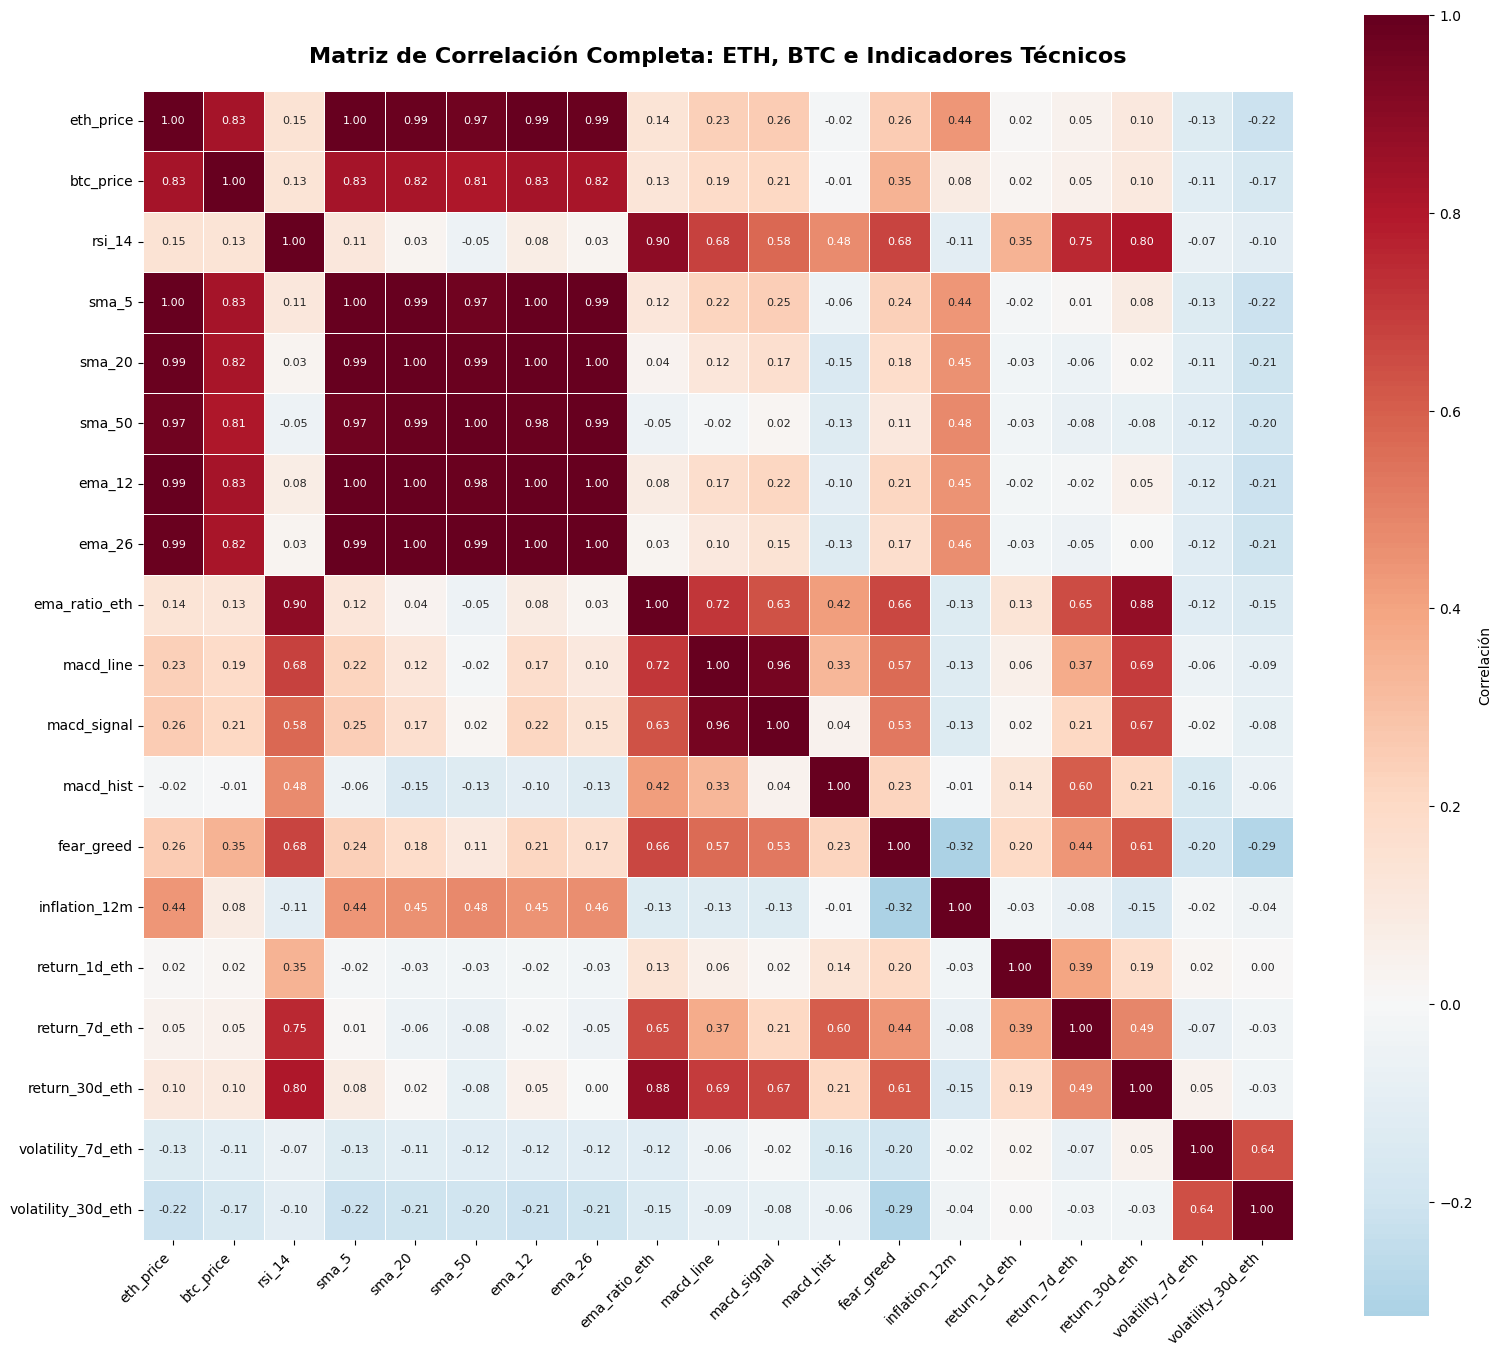

🏆 CORRELACIÓN CON ETH_PRICE (Ordenado)
🟢 eth_price                 r= 1.0000 ⭐⭐⭐⭐⭐
🟢 sma_5                     r= 0.9975 ⭐⭐⭐⭐
🟢 ema_12                    r= 0.9948 ⭐⭐⭐⭐
🟢 ema_26                    r= 0.9875 ⭐⭐⭐⭐
🟢 sma_20                    r= 0.9874 ⭐⭐⭐⭐
🟢 sma_50                    r= 0.9650 ⭐⭐⭐⭐
🟢 btc_price                 r= 0.8346 ⭐⭐⭐⭐
🟢 inflation_12m             r= 0.4368 ⭐⭐
🟡 fear_greed                r= 0.2599 ⭐
🟡 macd_signal               r= 0.2554 ⭐
🟡 macd_line                 r= 0.2348 ⭐
🔴 rsi_14                    r= 0.1461 
🔴 ema_ratio_eth             r= 0.1406 
🔴 return_30d_eth            r= 0.1034 
🔴 return_7d_eth             r= 0.0475 
🔴 return_1d_eth             r= 0.0184 
🔴 macd_hist                 r=-0.0218 
🔴 volatility_7d_eth         r=-0.1319 
🔴 volatility_30d_eth        r=-0.2171 ⭐

🏆 CORRELACIÓN CON BTC_PRICE (Ordenado)
🟢 btc_price                 r= 1.0000 ⭐⭐⭐⭐⭐
🟢 eth_price                 r= 0.8346 ⭐⭐⭐⭐
🟢 sma_5                     r= 0.8323 ⭐⭐⭐⭐
🟢 ema_12       

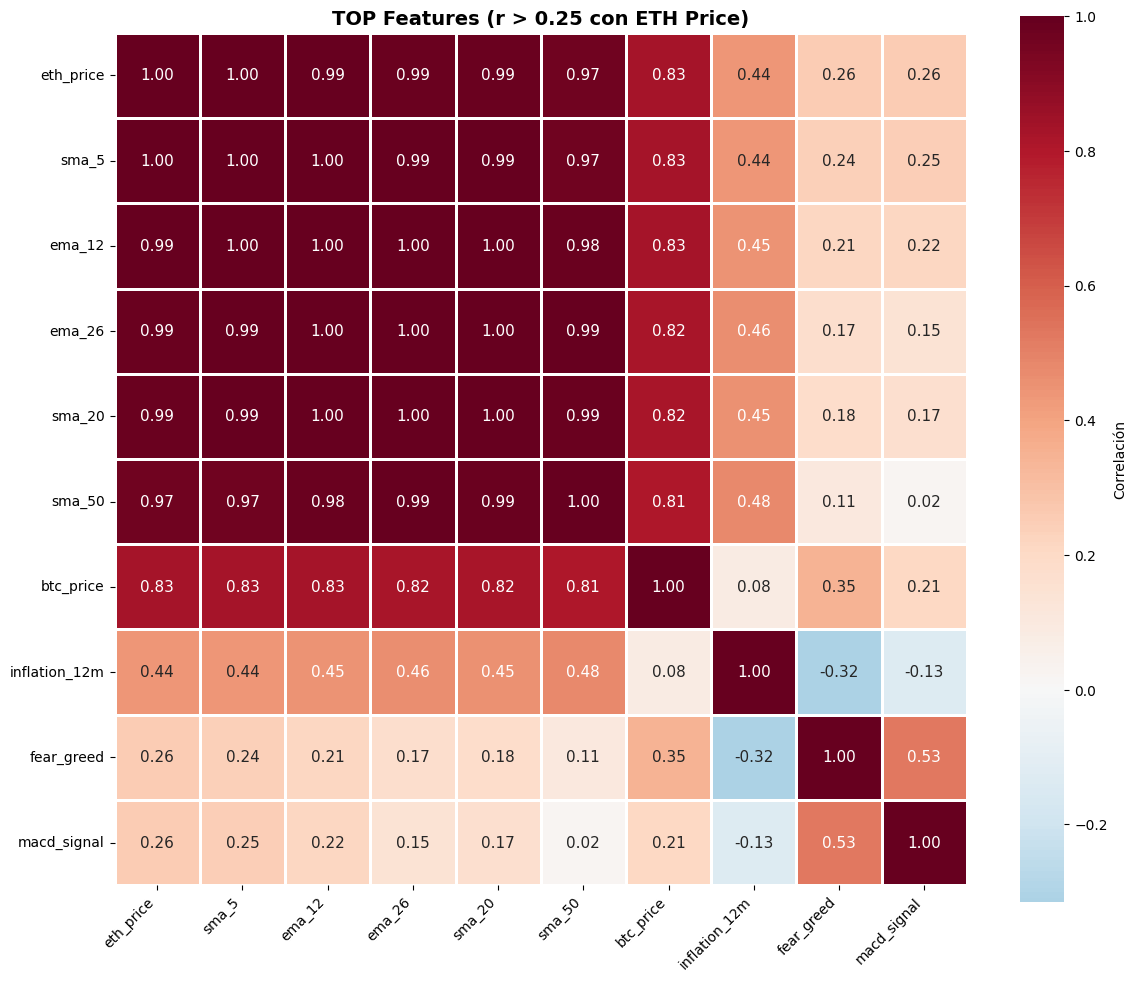

✅ Guardado: scatter_eth_indicators.png



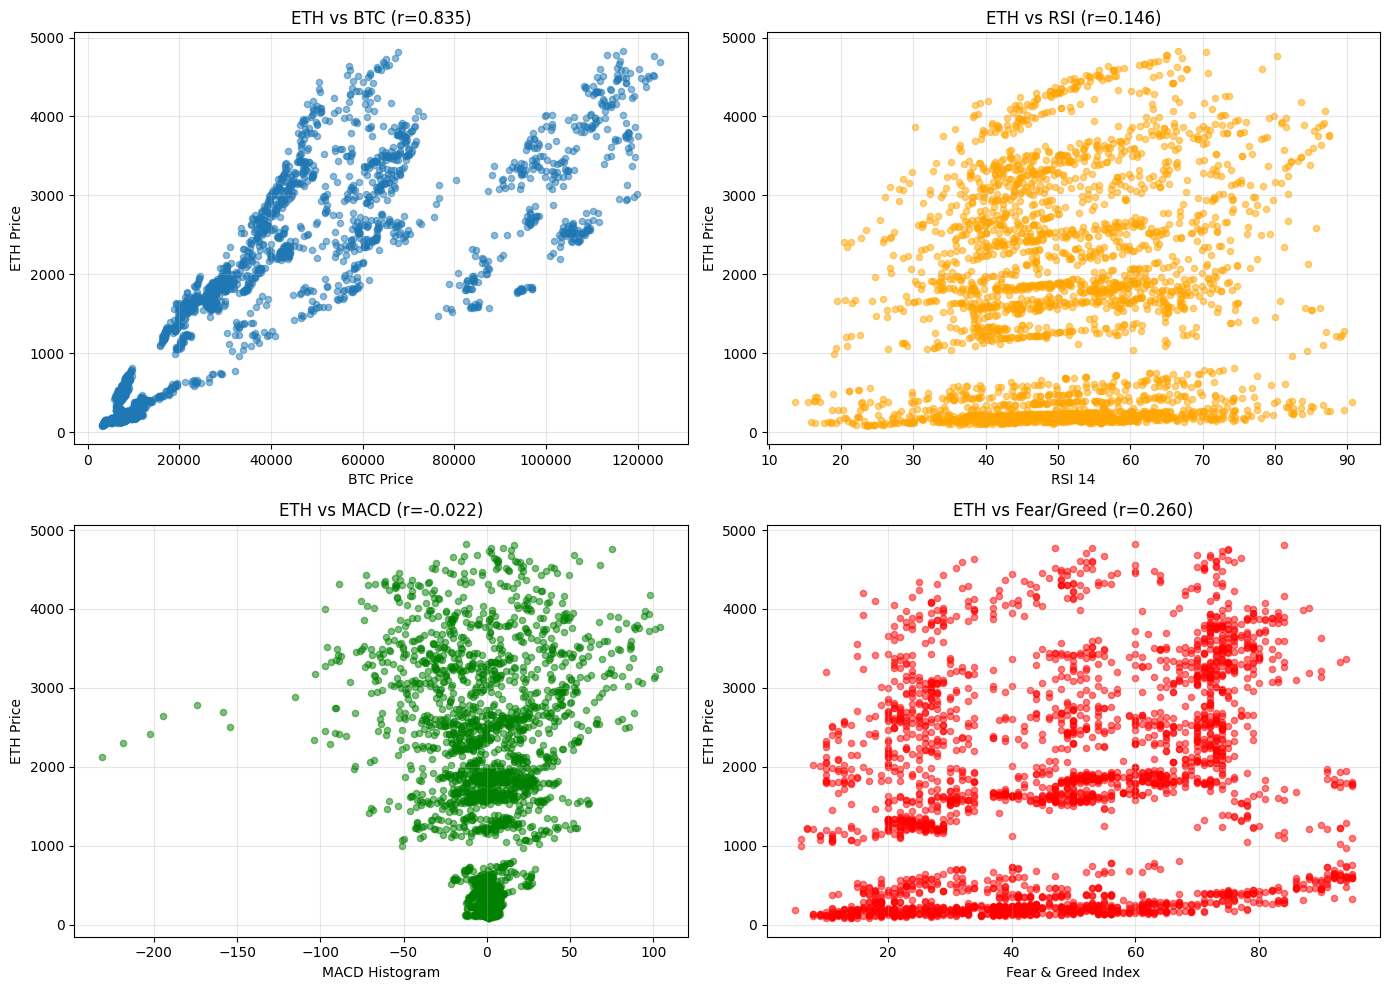

📊 RESUMEN PARA LSTM: TOP 10 FEATURES POR CORRELACIÓN
 1. sma_5                          r= 0.9975
 2. ema_12                         r= 0.9948
 3. ema_26                         r= 0.9875
 4. sma_20                         r= 0.9874
 5. sma_50                         r= 0.9650
 6. btc_price                      r= 0.8346
 7. inflation_12m                  r= 0.4368
 8. fear_greed                     r= 0.2599
 9. macd_signal                    r= 0.2554
10. macd_line                      r= 0.2348

✨ Matriz guardada: correlation_matrix_full.csv


In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar datos con indicadores
df = pd.read_csv(r"C:\Users\josit\CUARTO CURSO\TFG\TFG_DEF\data\csv\clean\crypto_with_indicators_manual.csv")
df['date'] = pd.to_datetime(df['date'])

print(f"📊 Dataset: {len(df)} filas, {df['date'].min()} a {df['date'].max()}\n")

# Seleccionar columnas relevantes (ETH, BTC, e indicadores)
columns_to_analyze = [
    'eth_price', 'btc_price',
    'rsi_14', 'sma_5', 'sma_20', 'sma_50',
    'ema_12', 'ema_26', 'ema_ratio_eth',
    'macd_line', 'macd_signal', 'macd_hist',
    'fear_greed', 'inflation_12m',
    'return_1d_eth', 'return_7d_eth', 'return_30d_eth',
    'volatility_7d_eth', 'volatility_30d_eth'
]

# Filtrar solo las columnas que existen
columns_actual = [col for col in columns_to_analyze if col in df.columns]

print(f"Columnas analizadas: {columns_actual}\n")

# Crear matriz de correlación
corr_matrix = df[columns_actual].corr()

# ============================================================================
# HEATMAP 1: CORRELACIÓN COMPLETA (GRANDE)
# ============================================================================
plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdBu_r',
    center=0,
    square=True,
    fmt='.2f',
    cbar_kws={'label': 'Correlación'},
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title('Matriz de Correlación Completa: ETH, BTC e Indicadores Técnicos', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_matrix_eth_btc_indicators.png', dpi=300, bbox_inches='tight')
print("✅ Guardado: correlation_matrix_eth_btc_indicators.png\n")
plt.show()

# ============================================================================
# ANÁLISIS: ETH PRICE vs TODO
# ============================================================================
print("="*70)
print("🏆 CORRELACIÓN CON ETH_PRICE (Ordenado)")
print("="*70)

corr_eth = corr_matrix['eth_price'].sort_values(ascending=False)
for feature, corr in corr_eth.items():
    stars = '⭐' * int(abs(corr)*5)
    color = '🔴' if corr < 0.15 else '🟡' if corr < 0.35 else '🟢'
    print(f"{color} {feature:<25} r={corr:>7.4f} {stars}")

# ============================================================================
# ANÁLISIS: BTC PRICE vs TODO
# ============================================================================
print("\n" + "="*70)
print("🏆 CORRELACIÓN CON BTC_PRICE (Ordenado)")
print("="*70)

corr_btc = corr_matrix['btc_price'].sort_values(ascending=False)
for feature, corr in corr_btc.items():
    stars = '⭐' * int(abs(corr)*5)
    color = '🔴' if corr < 0.15 else '🟡' if corr < 0.35 else '🟢'
    print(f"{color} {feature:<25} r={corr:>7.4f} {stars}")

# ============================================================================
# ANÁLISIS: ETH vs BTC
# ============================================================================
print("\n" + "="*70)
print("🎯 CORRELACIÓN ETH vs BTC")
print("="*70)

corr_eth_btc = corr_matrix.loc['eth_price', 'btc_price']
print(f"  ETH Price ↔ BTC Price: r = {corr_eth_btc:.4f} ⭐⭐⭐⭐⭐")
print(f"  → Bitcoin y Ethereum se mueven juntos al {abs(corr_eth_btc)*100:.1f}%\n")

# ============================================================================
# HEATMAP 2: SOLO TOP FEATURES
# ============================================================================
# Seleccionar TOP features (correlación > 0.3 con eth_price)
top_features = corr_eth[abs(corr_eth) > 0.25].index.tolist()

if len(top_features) > 3:
    top_corr_matrix = df[top_features].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        top_corr_matrix,
        annot=True,
        cmap='RdBu_r',
        center=0,
        square=True,
        fmt='.2f',
        cbar_kws={'label': 'Correlación'},
        linewidths=1,
        annot_kws={"size": 11}
    )
    plt.title(f'TOP Features (r > 0.25 con ETH Price)', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('correlation_matrix_top_features.png', dpi=300, bbox_inches='tight')
    print("✅ Guardado: correlation_matrix_top_features.png\n")
    plt.show()

# ============================================================================
# SCATTER PLOTS: ETH vs BTC + Indicadores
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ETH vs BTC
axes[0, 0].scatter(df['btc_price'], df['eth_price'], alpha=0.5, s=20)
axes[0, 0].set_xlabel('BTC Price')
axes[0, 0].set_ylabel('ETH Price')
axes[0, 0].set_title(f'ETH vs BTC (r={corr_eth_btc:.3f})')
axes[0, 0].grid(True, alpha=0.3)

# ETH vs RSI
if 'rsi_14' in df.columns:
    axes[0, 1].scatter(df['rsi_14'], df['eth_price'], alpha=0.5, s=20, color='orange')
    corr_rsi = df['eth_price'].corr(df['rsi_14'])
    axes[0, 1].set_xlabel('RSI 14')
    axes[0, 1].set_ylabel('ETH Price')
    axes[0, 1].set_title(f'ETH vs RSI (r={corr_rsi:.3f})')
    axes[0, 1].grid(True, alpha=0.3)

# ETH vs MACD
if 'macd_hist' in df.columns:
    axes[1, 0].scatter(df['macd_hist'], df['eth_price'], alpha=0.5, s=20, color='green')
    corr_macd = df['eth_price'].corr(df['macd_hist'])
    axes[1, 0].set_xlabel('MACD Histogram')
    axes[1, 0].set_ylabel('ETH Price')
    axes[1, 0].set_title(f'ETH vs MACD (r={corr_macd:.3f})')
    axes[1, 0].grid(True, alpha=0.3)

# ETH vs Fear/Greed
if 'fear_greed' in df.columns:
    axes[1, 1].scatter(df['fear_greed'], df['eth_price'], alpha=0.5, s=20, color='red')
    corr_fg = df['eth_price'].corr(df['fear_greed'])
    axes[1, 1].set_xlabel('Fear & Greed Index')
    axes[1, 1].set_ylabel('ETH Price')
    axes[1, 1].set_title(f'ETH vs Fear/Greed (r={corr_fg:.3f})')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_eth_indicators.png', dpi=300, bbox_inches='tight')
print("✅ Guardado: scatter_eth_indicators.png\n")
plt.show()

# ============================================================================
# RESUMEN PARA LSTM
# ============================================================================
print("="*70)
print("📊 RESUMEN PARA LSTM: TOP 10 FEATURES POR CORRELACIÓN")
print("="*70)

top_10 = corr_eth.drop('eth_price').head(10)
for i, (feature, corr) in enumerate(top_10.items(), 1):
    print(f"{i:2d}. {feature:<30} r={corr:>7.4f}")

# Guardar matriz
corr_matrix.to_csv('correlation_matrix_full.csv')
print(f"\n✨ Matriz guardada: correlation_matrix_full.csv")
